In [281]:
# to_save, to_load = False, True
session_file = "./tmp/TIC_281728275_EW_contaminated_by_TIC_281728276.ipynb.pkl"

# # load/save the notebook session
# # https://dill.readthedocs.io/en/latest/
# if True: 
#     import sys
#     if "../" not in sys.path:  # to get my usual helpers at base dir
#         sys.path.append("../")
#     if "../eb_with_diff_sb_period/etv/" not in sys.path:  # for etvp
#         sys.path.append("../eb_with_diff_sb_period/etv/")
#     import dill
#     dill.load_module(session_file)
#     %matplotlib inline
#     print(f"Notebook session loaded from  {session_file}")

# if True:  # save the notebook session
#     import dill
#     dill.dump_module(session_file)
#     print(f"Notebook session saved in {session_file}")


Notebook session saved in ./tmp/TIC_281728275_EW_contaminated_by_TIC_281728276.ipynb.pkl


In [1]:
import sys
if "../" not in sys.path:  # to get my usual helpers at base dir
    sys.path.append("../")

import lightkurve as lk
from lightkurve_ext import of_sector, of_sectors, of_2min_cadences
import lightkurve_ext as lke
from lightkurve_ext import TransitTimeSpec, TransitTimeSpecList
import lightkurve_ext_tess as lket
import lightkurve_ext_pg as lke_pg
import lightkurve_ext_pg_runner as lke_pg_runner
import tic_plot as tplt

import asyncio_compat

import math
import re
import warnings

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as matplotlib

import pandas as pd
import astropy as astropy
from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy.time import Time, TimeDelta
from astropy.io import fits

from matplotlib.ticker import (FormatStrFormatter, AutoMinorLocator)

from importlib import reload # useful during development to reload packages

from IPython.display import display, HTML, Javascript, clear_output

display(HTML("<style>.container { width:99% !important; }</style>"))  # Jupyter 6
display(HTML("<style>.jp-Notebook { --jp-notebook-max-width: 98%; }</style>"))  # Jupyter 7


# No longer works in Jupyter 7+
display(Javascript("""
// export notebook url to Python for bokeh-based interactive features
if (window["IPython"] != null) {
  IPython.notebook.kernel.execute(`notebook_url = "${window.location.origin}"`);
} else {
  console.warn("IPython js object not available (in Jupyter 7). Hardcode notebook_url in the notebook itself instead.")
}
"""));
notebook_url = "localhost:8888"

%matplotlib inline

# data cache config
lk_download_dir = '../data'
if hasattr(lk, "conf"):  # default download dir
    lk.conf.cache_dir = lk_download_dir

# make markdown table aligned to the left of the cell output (instead of center)
display(HTML("<style>table {margin-left: 4ch;}</style>"))

C:\pkg\_winNonPortables\miniforge3\envs\my_lk_plus4\Lib\site-packages\lightkurve\prf\__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(
C:\pkg\_winNonPortables\miniforge3\envs\my_lk_plus4\Lib\site-packages\lightkurve\config\__init__.py:119: UserWarning: The default Lightkurve cache directory, used by download(), etc., has been moved to C:\Users\SL\.lightkurve\cache. Please move all the files in the legacy directory C:\Users\SL\.lightkurve-cache to the new location and remove the legacy directory. Refer to https://lightkurve.github.io/lightkurve/reference/config.html#default-cache-directory-migration for more information.
  warnings.warn(


<IPython.core.display.Javascript object>

# TIC 281728275  Analysis (EW)

- revising existing entry NSV 295, primarily on position and identification (existing entry IDed the source be the nearby TYC 8466-913-1 / TIC 281728276)
- https://vsx.aavso.org/index.php?view=detail.top&oid=13977
- also refit epoch/period/magnitudes

## TESS Data

primarily for epoch / period (amplitude: TBD)

In [3]:
tic = 281728275

sr = lk.search_lightcurve(f"TIC{tic}", mission="TESS", cadence="short")  # , author="SPOC"
# display(sr_all)
# sr = sr_all
sr = lke.filter_by_priority(sr, author_priority = ["SPOC", "TESS-SPOC", "QLP"])
# sr = sr[sr.exptime == 20 * u.s]


astropy.table.pprint.conf.max_lines = 100  # to print all rows
display(sr)

lcc_tess = sr.download_all()
lcc_tess

#,mission,year,author,exptime,target_name,distance,proposal_id
,,,,s,,arcsec,
0,TESS Sector 29,2020,SPOC,120,281728275,0.0,G03102
1,TESS Sector 68,2023,SPOC,120,281728275,0.0,G05129
2,TESS Sector 69,2023,SPOC,120,281728275,0.0,G05129
3,TESS Sector 103,2026,SPOC,120,281728275,0.0,G08119
4,TESS Sector 104,2026,SPOC,120,281728275,0.0,G08119
5,TESS Sector 105,2026,SPOC,120,281728275,0.0,G08119


LightCurveCollection of 6 objects:
    0: <TessLightCurve LABEL="TIC 281728275" SECTOR=29 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    1: <TessLightCurve LABEL="TIC 281728275" SECTOR=68 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    2: <TessLightCurve LABEL="TIC 281728275" SECTOR=69 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    3: <TessLightCurve LABEL="TIC 281728275" SECTOR=103 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    4: <TessLightCurve LABEL="TIC 281728275" SECTOR=104 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    5: <TessLightCurve LABEL="TIC 281728275" SECTOR=105 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>

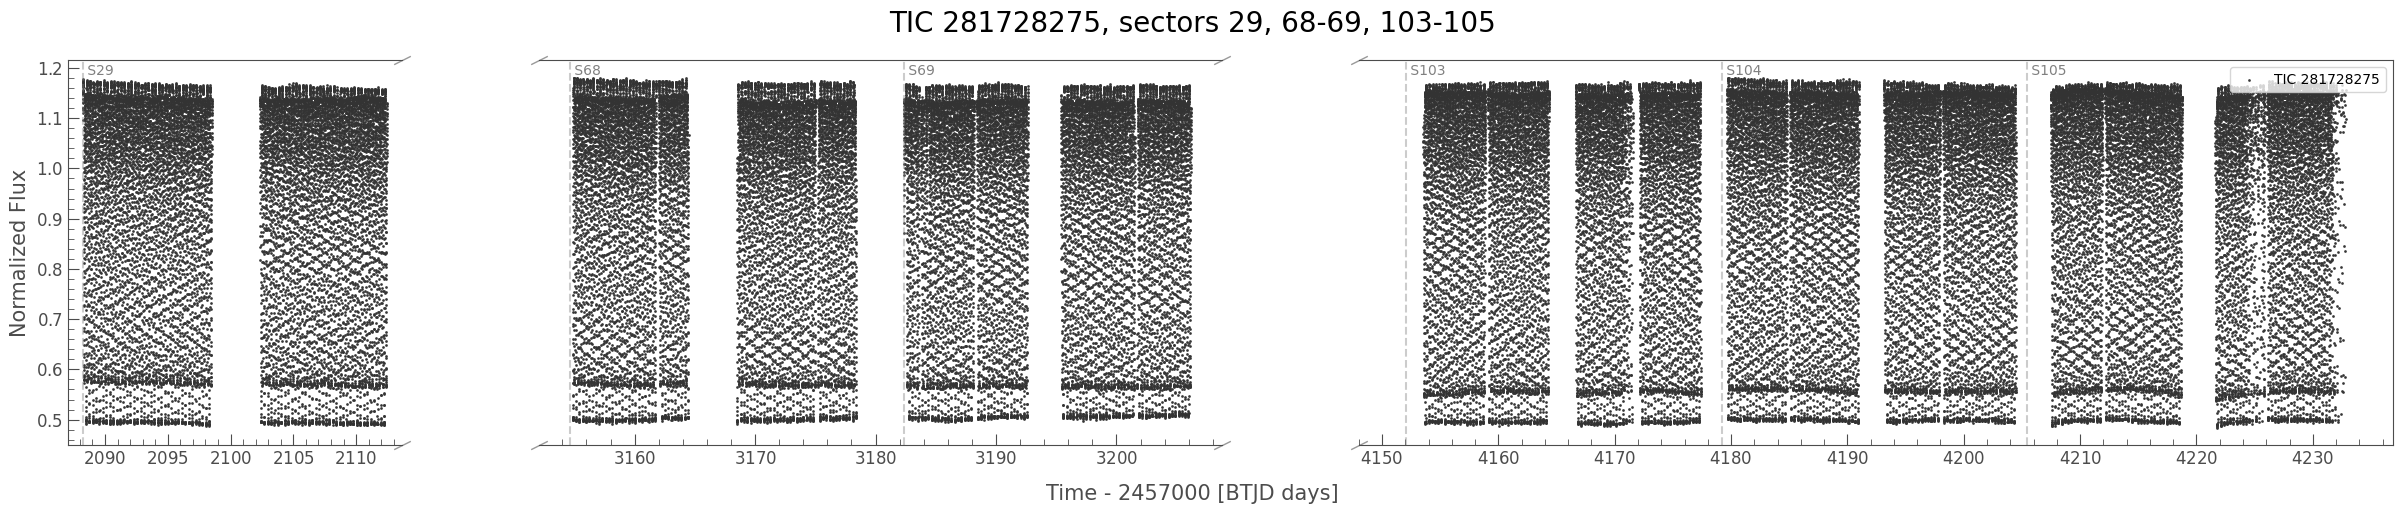

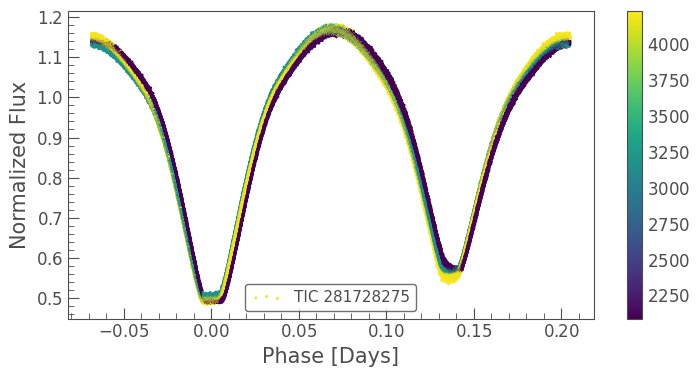

In [29]:
_lc = lke.stitch(
    lcc_tess,
    ignore_incompatible_column_warning=True,    
)

axs = tplt.plot_skip_data_gap(_lc, figsize=(30,5), s=4, alpha=0.9);
axs[0].get_figure().suptitle(f"{_lc.label}, sectors {lke.abbrev_sector_list(lc)}", fontsize=20);

_lc_f = _lc.fold(period=0.273365, epoch_time=Time(2088.465, format="btjd"),  wrap_phase=0.273365*0.75)  # rough initial epoch / period to gauge usefulness of the data
ax = tplt.scatter(_lc_f, c=_lc_f.time_original.value);

---

## Gaia DR3 info (coordinate, etc.)

In [14]:
# reload(lke)
# reload (lket)
rs_all_cols, rs, rs_html  = lket.search_gaiadr3_of_tics(tic, radius_arcsec=15, magnitude_range=None,  pm_error_factor=None, pm_range_fraction=None, pm_range_minimum=None, 
                                                        calc_separation_from_first_row=True,  # assuming the first row is the target, it'd calculate more accurately the separation for Gaia DR3 Main
                                                        compact_columns=True, also_return_html=True, also_return_astrophysical=False, verbose_html=True, include_nss_summary_in_html=False)
display(HTML(rs_html))

# from Gaia DR3
target_coord = SkyCoord(rs[0]["RAJ2000"], rs[0]["DEJ2000"], unit=(u.deg, u.deg), frame="icrs")
target_coord_dict = dict(ra=target_coord.ra.value, dec=target_coord.dec.value)

In [15]:
primary_name = "NSV 295"  # existing VSX name  # f"TIC {tic}"
print(primary_name)

NSV 295


## TESS data: convert to Mag / HJD

In [36]:
# # helper to review the data interactively
# tplt.plot_transit_interactive(_lc, figsize=(30, 8), plot_kwargs=dict(normalize=False, plot_kwargs=dict(s=25),));

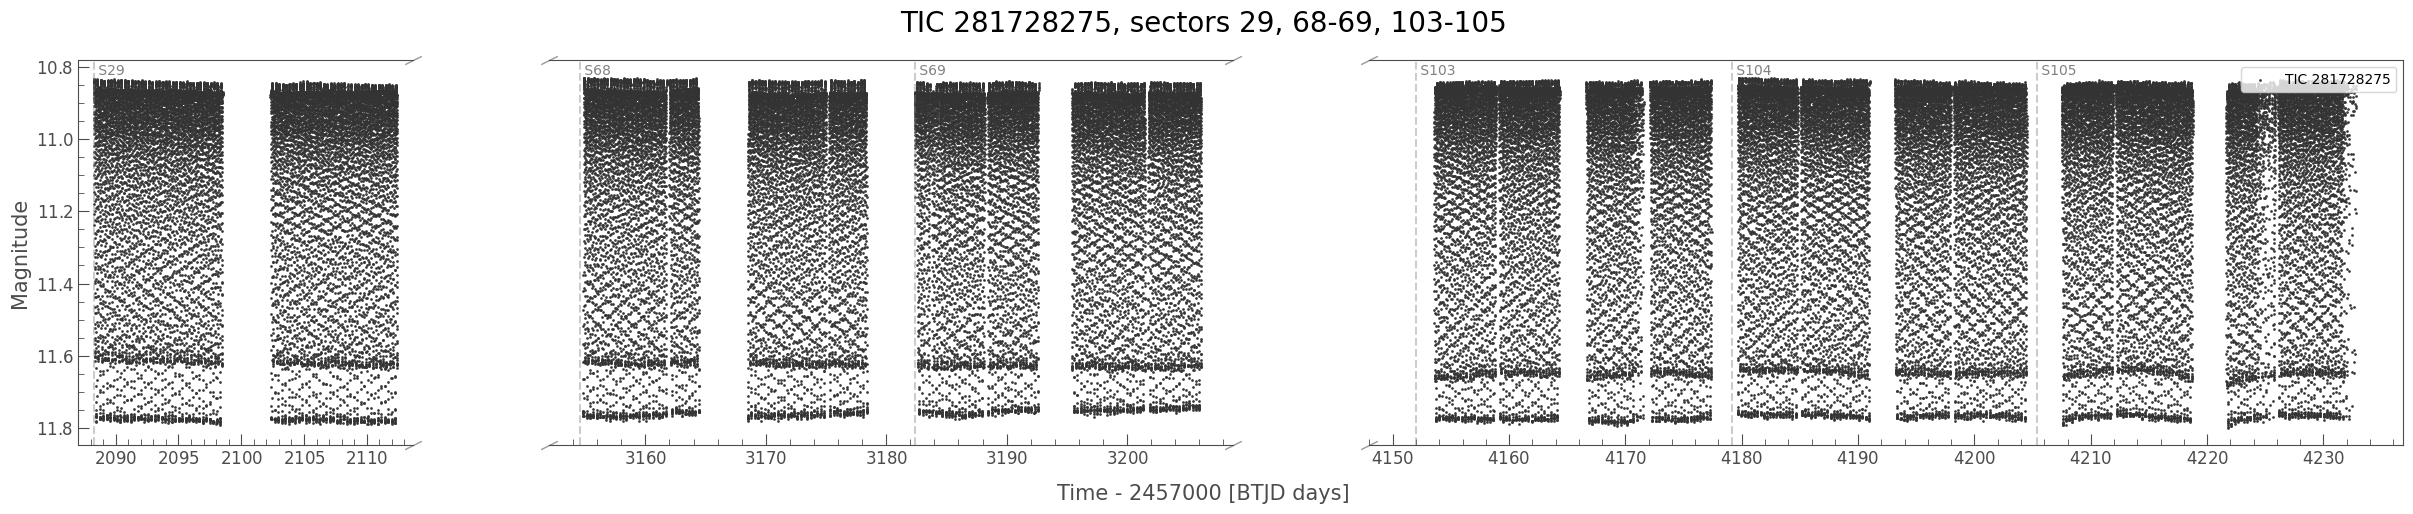

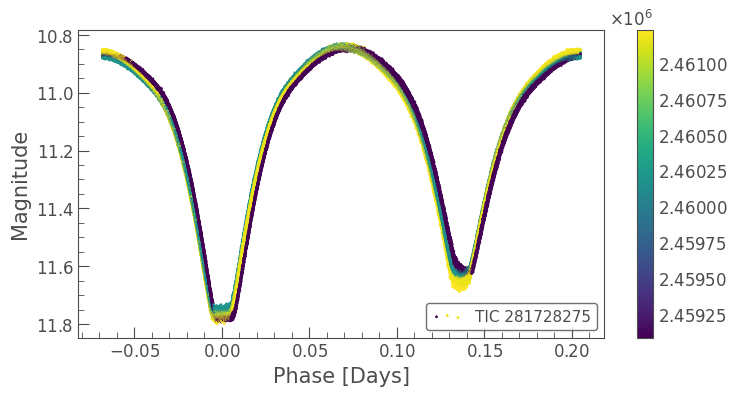

In [40]:
_lc = lke.stitch(
    lcc_tess,
    ignore_incompatible_column_warning=True,    
)
_lc  = lke.to_flux_in_mag_by_normalization(_lc)

axs = tplt.plot_skip_data_gap(_lc, figsize=(30,5), s=4, alpha=0.9);
axs[0].get_figure().suptitle(f"{_lc.label}, sectors {lke.abbrev_sector_list(lc)}", fontsize=20);

_lc = lke.convert_lc_time_to_hjd_utc(_lc, target_coord=target_coord, cache_dir=lk_download_dir)

_lc_f = _lc.fold(period=0.273365, epoch_time=Time(2088.465, format="btjd"),  wrap_phase=0.273365*0.75)  # rough initial epoch / period to gauge usefulness of the data
ax = tplt.scatter(_lc_f, c=_lc_f.time_original.value);

lc_tess = _lc

## ASAS-3 data

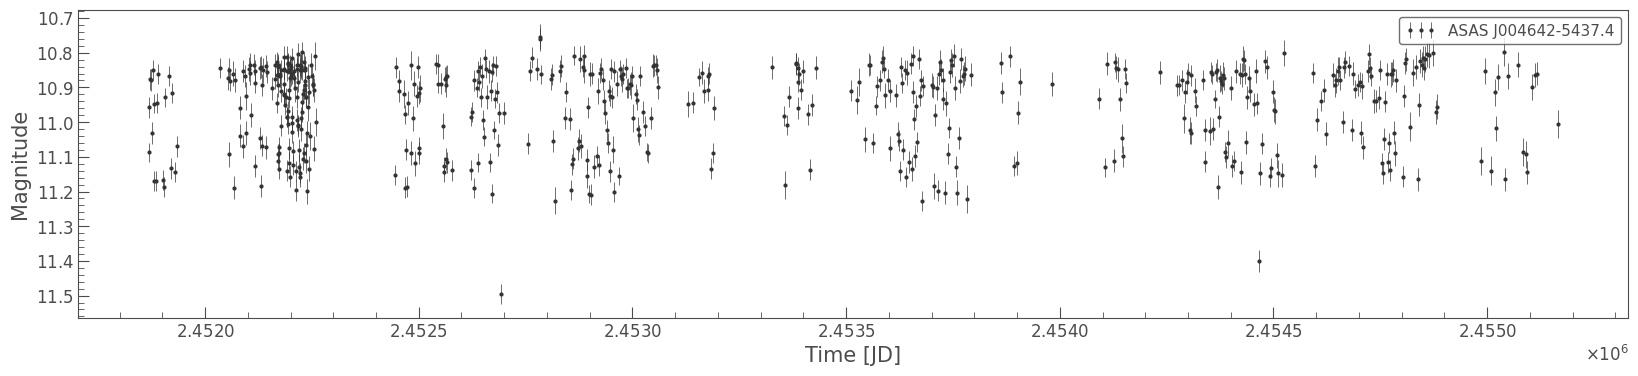

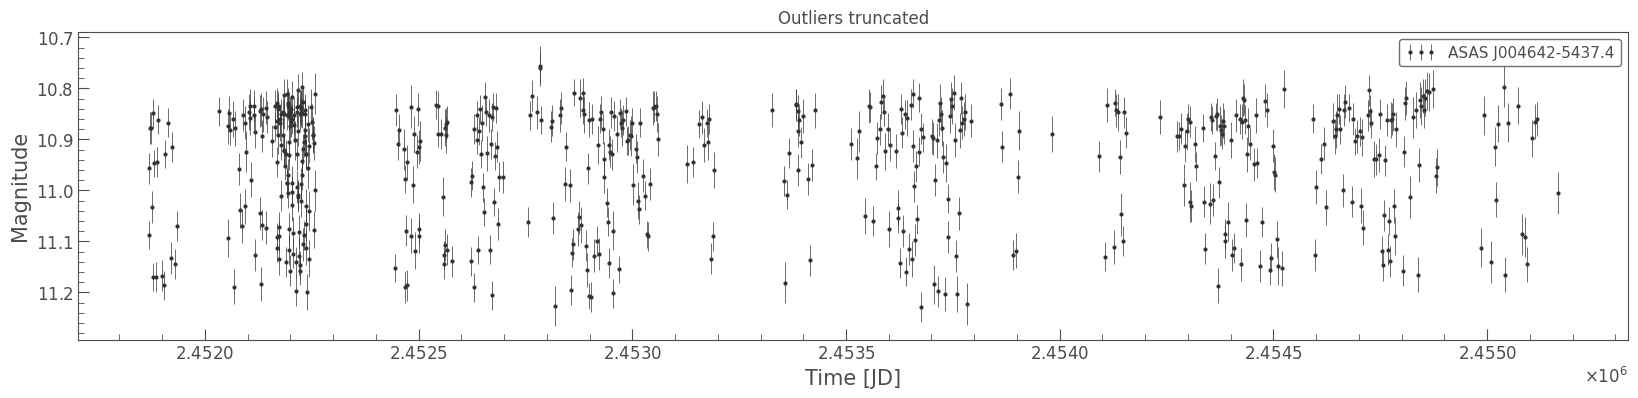

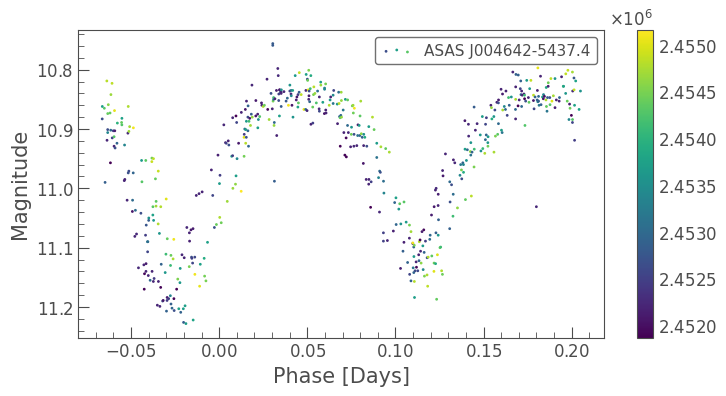

In [250]:
import lightkurve_ext_readers as lker
# reload(lker)

_lc = (
    lker.read_asas3("https://www.astrouw.edu.pl/cgi-asas/asas_cgi_get_data?004642-5437.4,asas3")
)

ax = tplt.lk_ax(figsize=(20, 4))
ax = tplt.errorbar(_lc, ax=ax);

_lc = _lc.truncate(None, 11.3, column="flux");
ax = tplt.lk_ax(figsize=(20, 4))
ax = tplt.errorbar(_lc, ax=ax);
ax.set_title("Outliers truncated");

_lc_f = _lc.fold(period=0.273365, epoch_time=Time(2088.466, format="btjd"),  wrap_phase=0.273365*0.75)  # rough initial epoch / period to gauge usefulness of the data
ax = tplt.scatter(_lc_f, c=_lc_f.time_original.value);

lc_asas3 = _lc  # keep the reference in a meaninfgul name for use in subsequent cells

## Gaia DR3 data

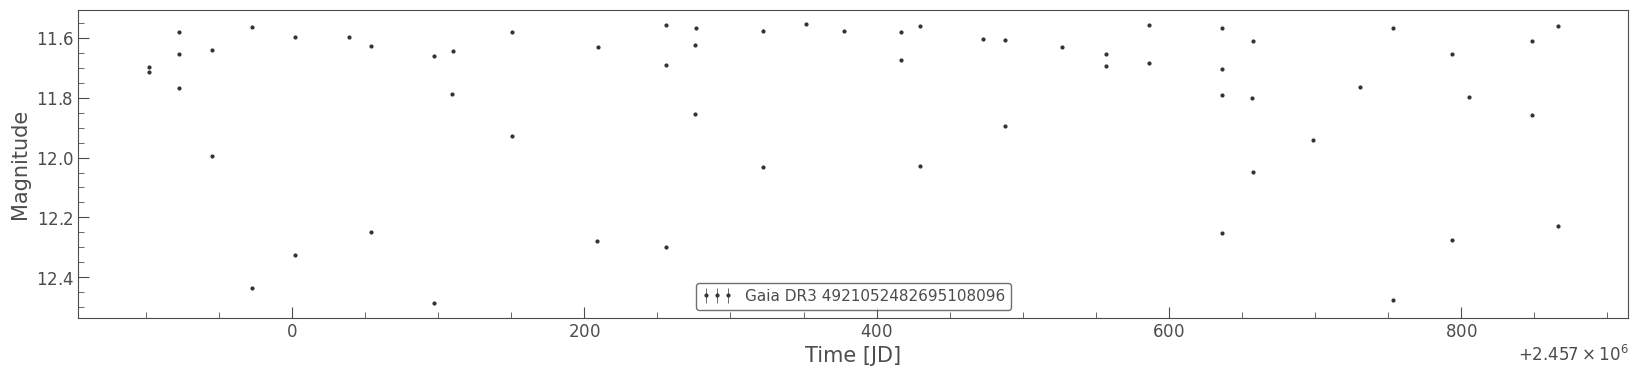

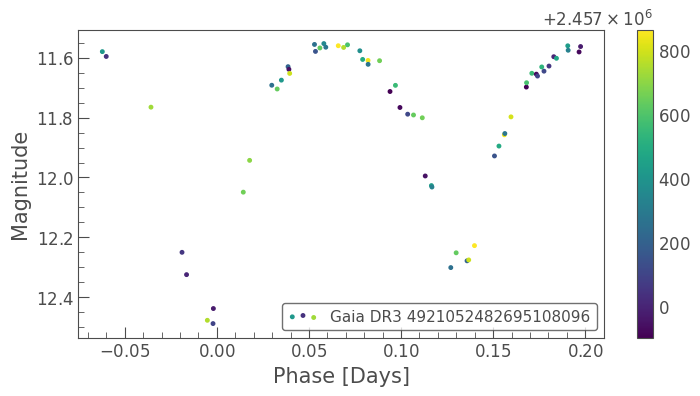

In [32]:
_lc = lker.read_gaia_dr3_lc_from_vizier(4921052482695108096, flux_column="Vmag")

ax = tplt.lk_ax(figsize=(20, 4))
ax = tplt.errorbar(_lc, ax=ax);

_lc_f = _lc.fold(period=0.273365, epoch_time=Time(2088.465, format="btjd"),  wrap_phase=0.273365*0.75)  # rough initial epoch / period to gauge usefulness of the data
ax = tplt.scatter(_lc_f, s=25, c=_lc_f.time_original.value);


_lc = lke.convert_lc_time_to_hjd_utc(_lc, target_coord=target_coord, cache_dir=lk_download_dir, cache_key="gdr4921052482695108096")
lc_gdr3 = _lc 


## Combining data


TESS # data points: 103148
ASAS-3 # data points: 571
Gaia DR3 V # data points: 64


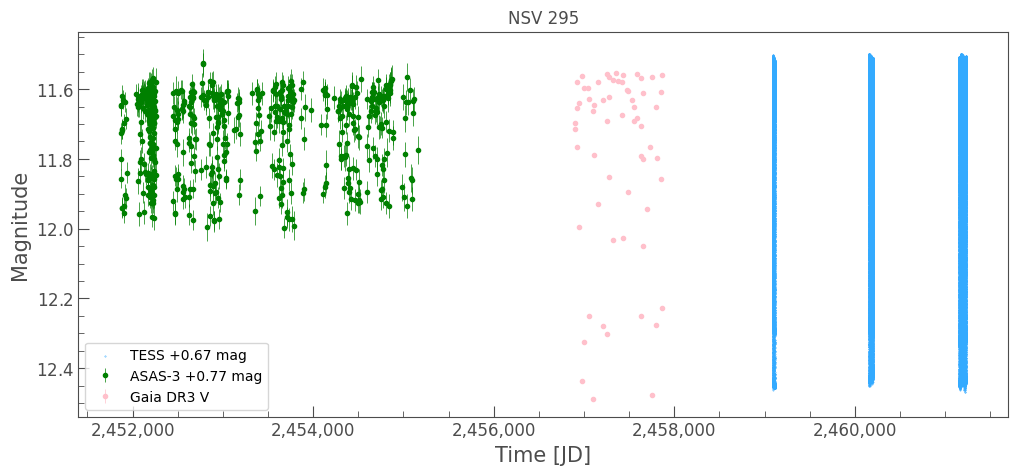

In [41]:
# Convert the data to magnitude and HJD/UTC

import lightkurve_ext_multi_sources as lkem
reload(lkem)


lc_combined_dict = lkem.combine_multi_bands_and_shift(
    {"TESS": lc_tess, 
     "ASAS-3": lc_asas3,
     "Gaia DR3 V": lc_gdr3,
    }, 
    shift_to="Gaia DR3 V",
)

for k in lc_combined_dict.keys():
    print(f"{k} # data points:", len(lc_combined_dict[k]))

ax = lkem.plot_multi_bands(lc_combined_dict, figsize=(12, 5), target_name=primary_name);
# ax.set_ylim(None, 7.995);

## Initial epoch / period / duration

In [44]:
lkem.get_default_plot_multi_bands_options_copy()

[('scatter', {'c': '#3AF', 's': 0.1, 'alpha': 1.0}),
 ('errorbar',
  {'marker': '.',
   'markersize': None,
   'c': 'green',
   'linewidth': 0.5,
   'ls': 'none'}),
 ('errorbar',
  {'marker': '.',
   'markersize': None,
   'c': 'pink',
   'linewidth': 0.5,
   'ls': 'none'}),
 ('errorbar',
  {'marker': '.',
   'markersize': None,
   'c': 'violet',
   'linewidth': 0.5,
   'ls': 'none'}),
 ('errorbar',
  {'marker': '.',
   'markersize': None,
   'c': 'orange',
   'linewidth': 0.5,
   'ls': 'none'})]

Adopted period / epoch / duration_hr:  0.273365 2459088.465 2.0


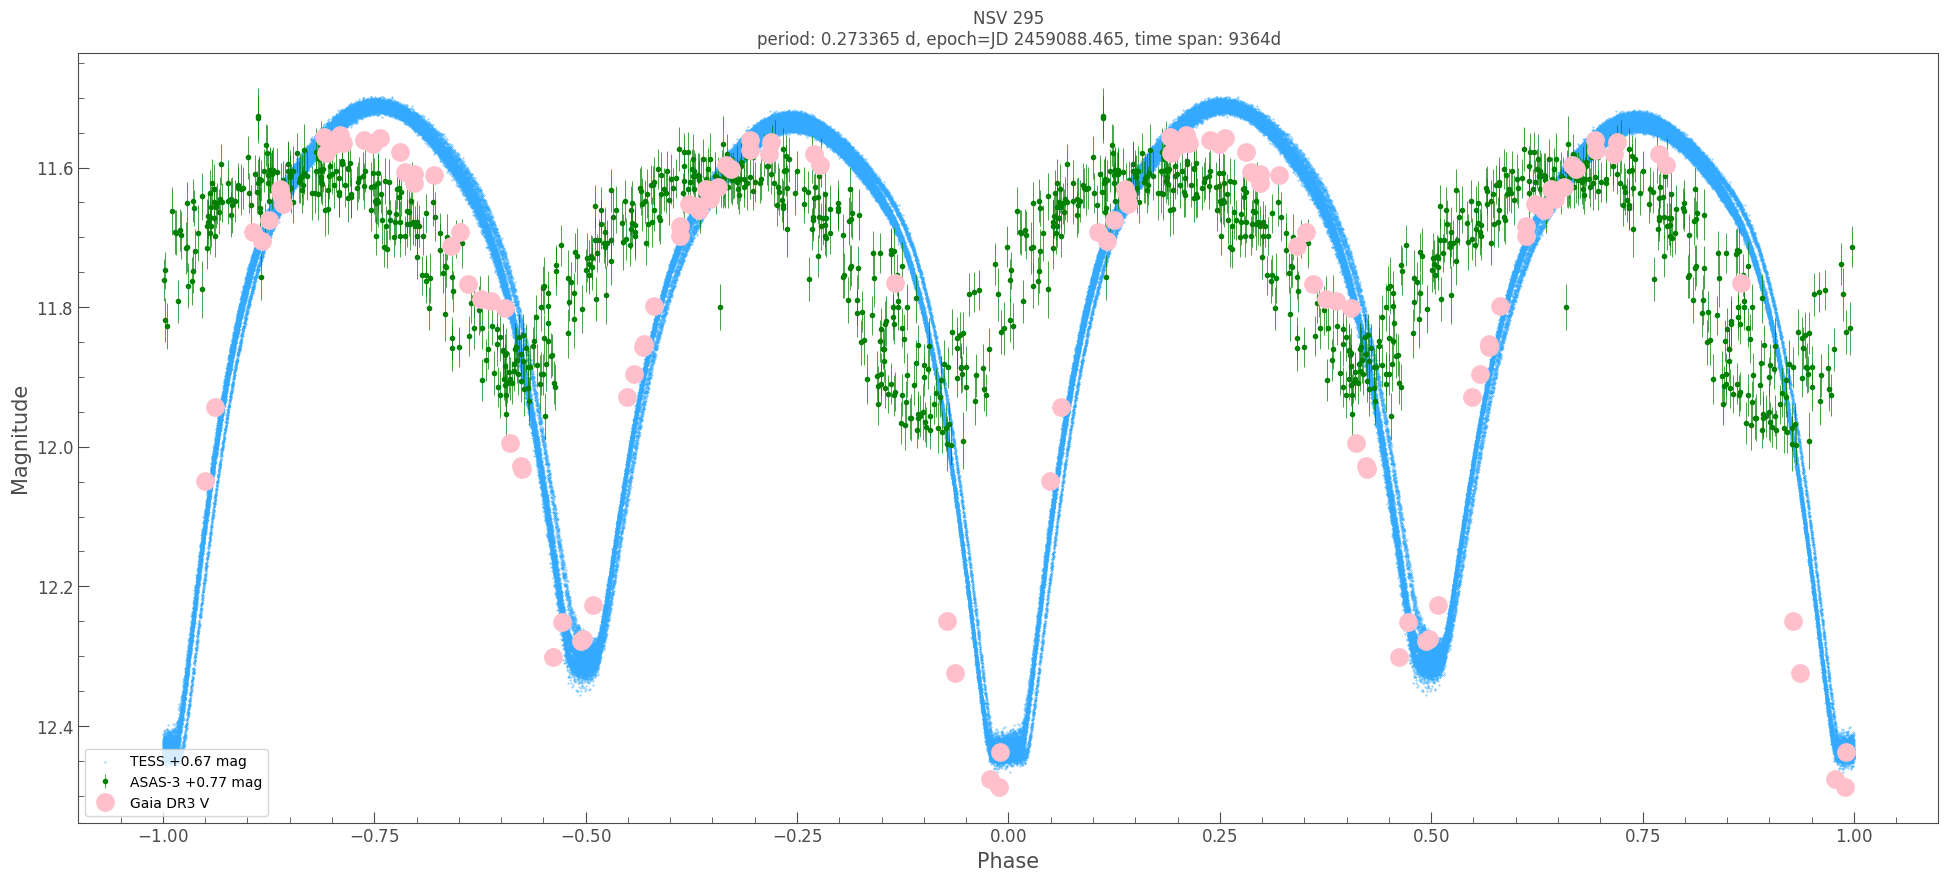

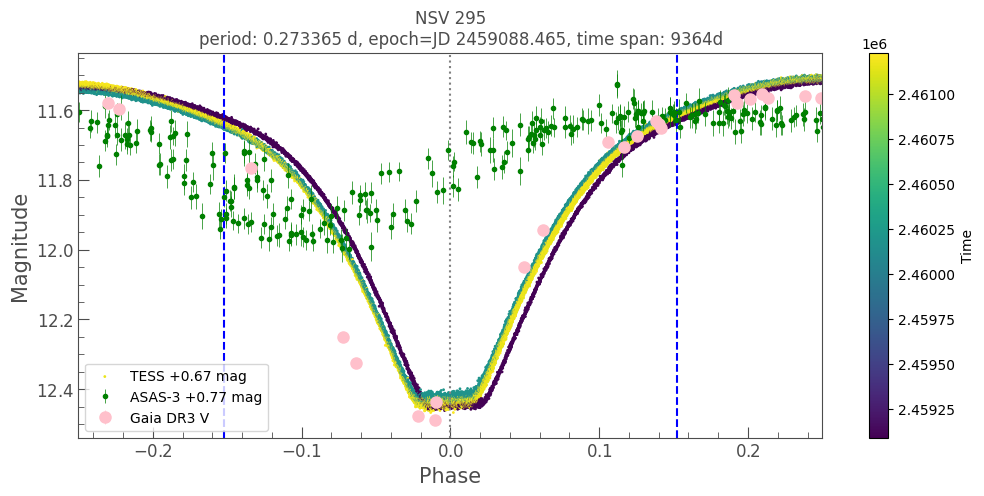

In [79]:
# reload(lkem)

# from TCE
# epoch=2088.33, duration_hr=0.5, period=0.273365, label="s0001s0069tce1", transit_depth_percent=30.3307,
# manaual adjusted to
# epoch=2088.465, duration_hr=1.0, period=0.273365
# current VSX period:  0.2733669 
# Gaid DR3 Var period: 0.2733661408798665

period_trial = 0.273365  # from TESS, 0.273366 would fit all data set better, but as the exapnse of TESS fit
epoch_time_btjd_trial = 2088.466
epoch_time_hjd_trial = round(lket.btjd_to_hjd_utc(epoch_time_btjd_trial, target_coord), 3)  # need 3 digit to ensure it does look off visually
duration_hr_min_i_trial = 2.0

# epoch_time_min_ii_btjd_trial = 
# epoch_time_min_ii_hjd_trial = round(lket.btjd_to_hjd_utc(epoch_time_min_ii_btjd_trial, target_coord), 2)  # need 3 digit to ensure it does look off visually
# duration_hr_min_ii_trial = 


print("Adopted period / epoch / duration_hr: ", period_trial, epoch_time_hjd_trial, duration_hr_min_i_trial)  # , duration_hr_min_ii_trial

# --- Plot them to verify ---

plot_options = lkem.get_default_plot_multi_bands_options_copy()
plot_options[2][1]["markersize"] = 25

ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_trial,
    epoch=Time(epoch_time_hjd_trial   , format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1    
    figsize=(24, 10),
    target_name=primary_name,
    plot_options=plot_options,
);
ax.legend(loc="lower left");
ylim = (None, None)
ax.set_ylim(*ylim);

# zoom plot Min I
# - make TESS more visible:  larger dots
plot_options_zoom = lkem.get_default_plot_multi_bands_options_copy()
plot_options_zoom[0][1]["s"] = 1
plot_options_zoom[0][1]["c"] = "_time_"
plot_options_zoom[2][1]["markersize"] = 16


ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_trial,
    epoch=Time(epoch_time_hjd_trial, format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
    target_name=primary_name,
    duration_hr=duration_hr_min_i_trial  ,  # for plotting only
    figsize=(12, 5), 
    plot_options=plot_options_zoom,
    # mag_shift_precision=2,
);
ax.legend(loc="lower left");
ax.axvline(0, c="gray", linestyle="dotted");
ax.set_xlim(-0.25, 0.25);  # to see primary in details
ax.set_ylim(*ylim);


# # zoom plot Min II
# ax, lc_f_res = lkem.fold_n_plot_multi_bands(
#     lc_combined_dict,
#     period=period_trial,
#     epoch=Time(epoch_time_min_ii_hjd_trial, format="jd", scale="utc"),
#     phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
#     target_name=primary_name,
#     duration_hr=duration_hr_min_ii_trial  ,  # for plotting only
#     figsize=(12, 5),
#     plot_options=plot_options_zoom,
#     # mag_shift_precision=2,
# );
# ax.legend(loc="lower left");
# ax.axvline(0, c="gray", linestyle="dotted");
# ax.set_xlim(-0.007, 0.007);  # to see primary in details
# ax.set_ylim(9.97, 9.952);


## Period refinement with Multi-band Lomb-Scargle (not useful)

In [99]:
import os; os.add_dll_directory(r"C:\msys64\mingw64\bin"); print("Added MinGW64 bin to_bytes os DLL path for my nifty-ls build.");
from importlib import reload
import nifty_ls
reload(nifty_ls.core)  # to ensure available backend are not cached with old values
nifty_ls.__version__

Added MinGW64 bin to_bytes os DLL path for my nifty-ls build.


'2.0.0a1.dev8+g18ab29062.d20260611'

0.13670050037606357 d


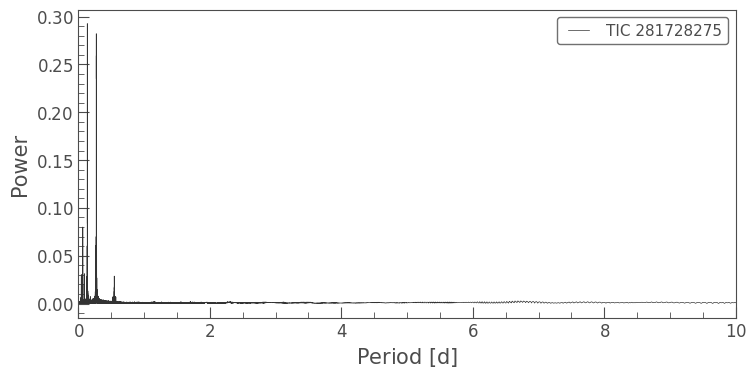

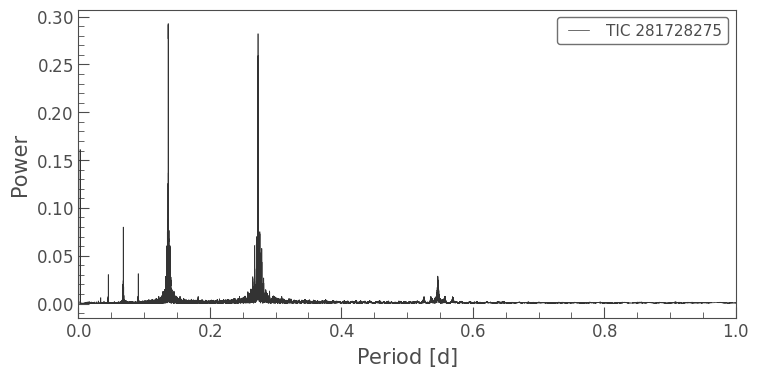

In [110]:
_pg = lke.stitch_lc_dict(lke.get_lc_dict_subset(lc_combined_dict, "TESS"), normalize=True).to_periodogram(ls_method="fastnifty_chi2", nterms=2, )  # oversample_factor=50
_freq_grid = _pg.frequency

print(_pg.period_at_max_power)

ax = _pg.plot(view="period");
ax.set_xlim(0, 10);

ax = _pg.plot(view="period");
ax.set_xlim(0, 1);

3859943
339559


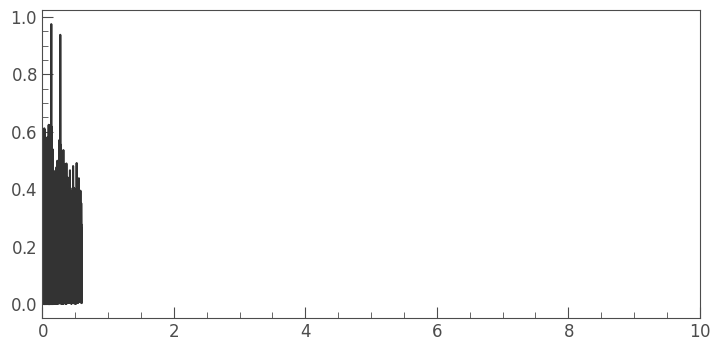

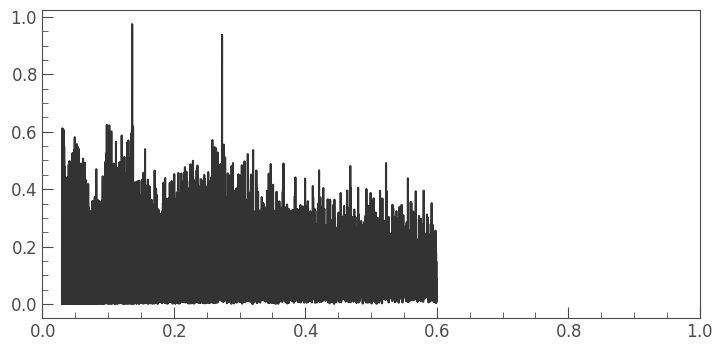

In [130]:
from astropy.timeseries import LombScargleMultiband

_lc = lke.stitch_lc_dict(lke.get_lc_dict_subset(lc_combined_dict, "Gaia DR3 V", "ASAS-3"), normalize=True).remove_nans()  

_ls = LombScargleMultiband(_lc.time, _lc.flux, _lc.source, _lc.flux_err, nterms_base=2, nterms_band=2)
# _frequencies, _power = _ls.autopower(method="flexible")

_frequencies = _freq_grid # use TESS data derived  frequency grid, the default one doesn't cover short-enough periods
print(len(_frequencies))
_frequencies = _frequencies[_frequencies.value > 1 / 0.6]  # cut off period > 0.6 d
_frequencies = _frequencies[_frequencies.value < 1 / 0.03]  # cut off period < 0.03 d
print(len(_frequencies))
_power = _ls.power(_frequencies, method="flexible")
_periods = 1 / _frequencies

ax = tplt.lk_ax()
ax.plot(_periods, _power, );
ax.set_xlim(0, 10);

ax = tplt.lk_ax()
ax.plot(_periods, _power, );
ax.set_xlim(0, 1);


In [139]:
period_maxpower = _periods[np.argmax(_power)]
print(period_maxpower)

_mask = _periods > 0.2 * u.d

period_2ndpower = (_periods[_mask])[np.argmax(_power[_mask])]
print(period_2ndpower)

0.13668307542286015 d
0.27336266634372103 d


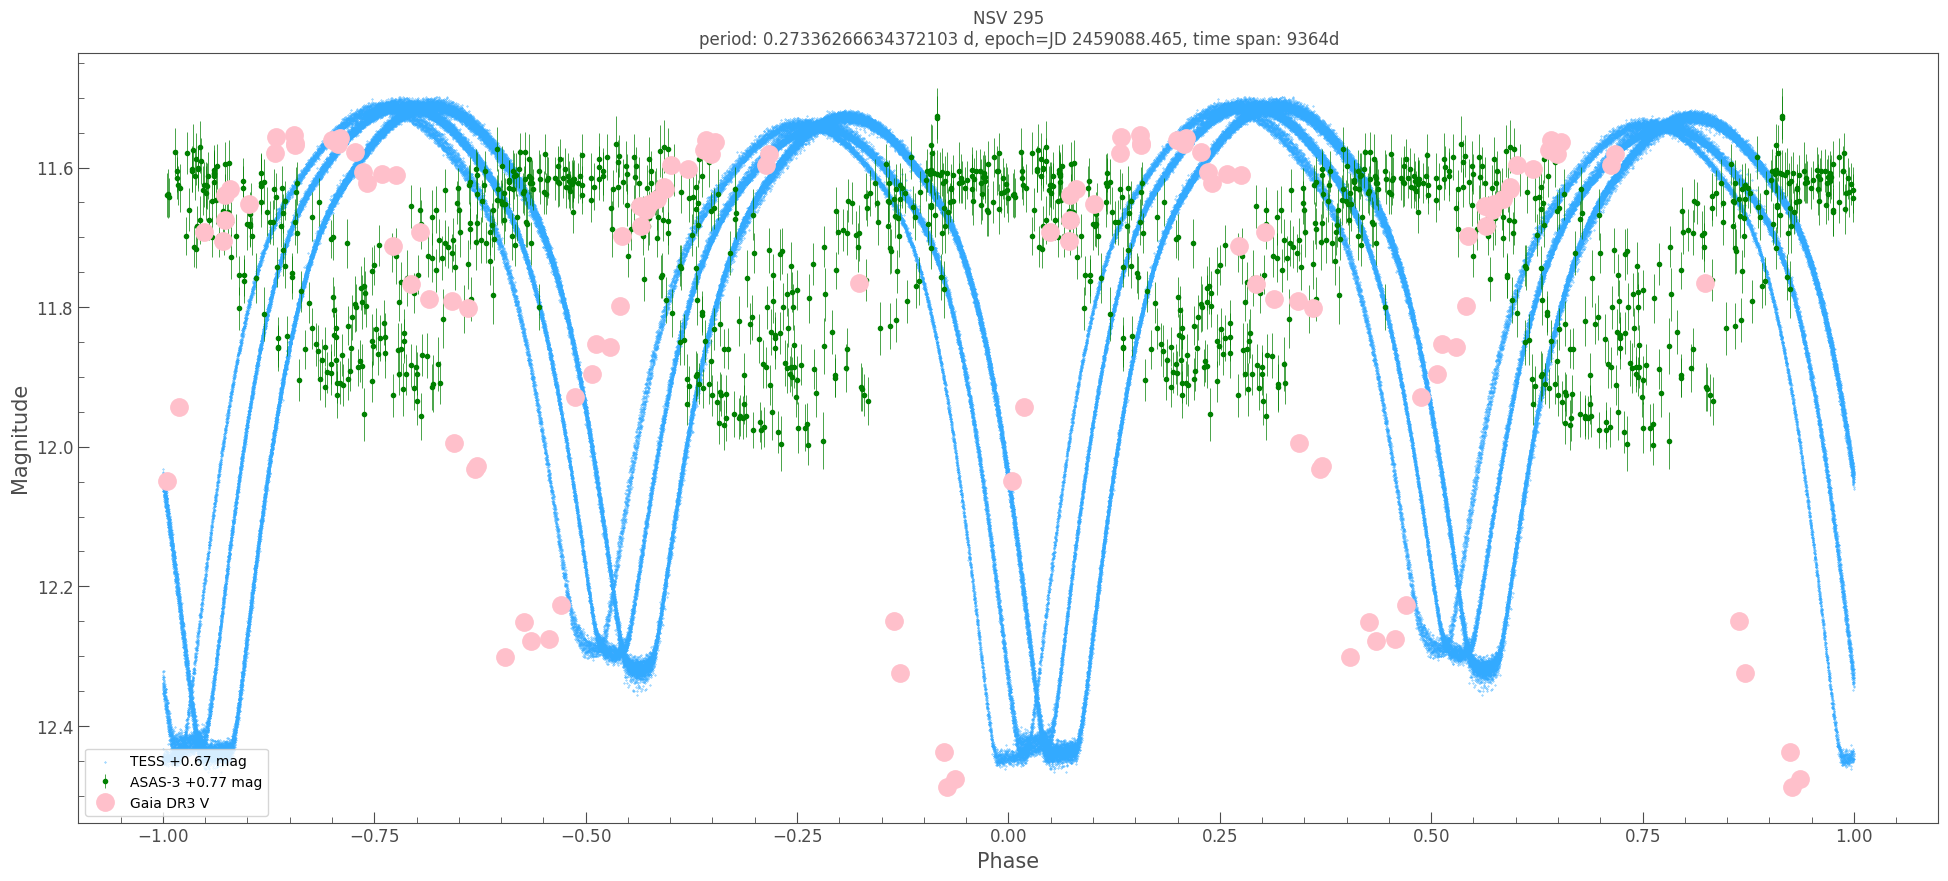

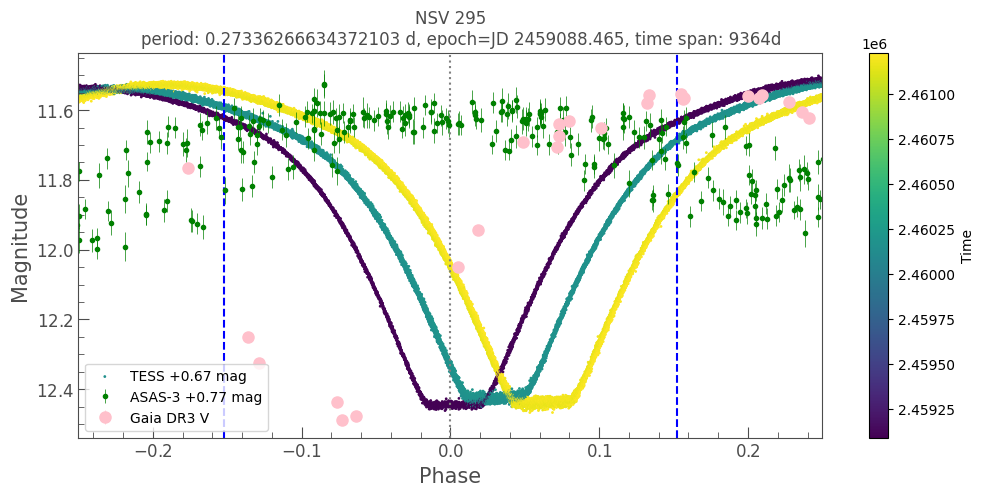

In [140]:
_p = 0.27336266634372103   # Multi-band Lomb-Scagle 
_t0 = epoch_time_hjd_trial

ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=_p, 
    epoch=Time(_t0, format="jd", scale="utc"),  
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1    
    figsize=(24, 10),
    target_name=primary_name,
    plot_options=plot_options,
);
ax.legend(loc="lower left");
ax.set_ylim(*ylim);

ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=_p,
    epoch=Time(_t0, format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
    target_name=primary_name,
    duration_hr=duration_hr_min_i_trial  ,  # for plotting only
    figsize=(12, 5), 
    plot_options=plot_options_zoom,
    # mag_shift_precision=2,
);
ax.legend(loc="lower left");
ax.axvline(0, c="gray", linestyle="dotted");
ax.set_xlim(-0.25, 0.25);  # to see primary in details
ax.set_ylim(*ylim);


## Period refinement with MCMC

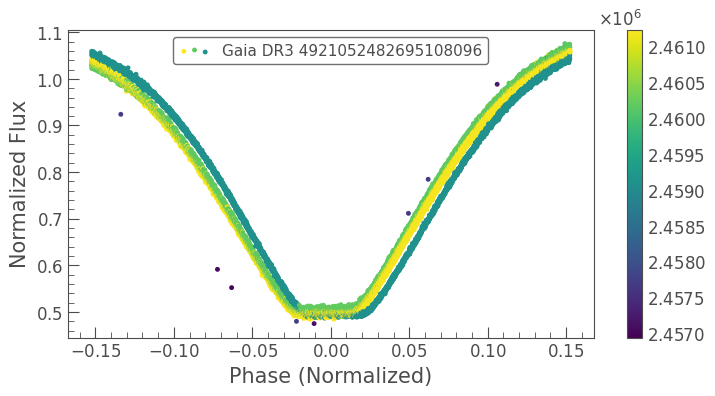

In [85]:
_lc = lke.stitch_lc_dict(lke.get_lc_dict_subset(lc_combined_dict, "TESS", "Gaia DR3 V"), normalize=True).remove_nans()  

lc_f_min_i = _lc.fold(epoch_time=epoch_time_hjd_trial, period=period_trial, normalize_phase=True)
lc_f_min_i = lc_f_min_i.truncate((0 - duration_hr_min_i_trial / 24 * 0.5) / period_trial, (0 + duration_hr_min_i_trial /24 * 0.5) / period_trial)
# lc_f_min_i = lc_f_min_i.truncate(None, 1.2, column="flux")  # crude outlier removal
ax1 = tplt.scatter(lc_f_min_i, c=lc_f_min_i.time_original.value, s=25);
# ax1 = tplt.errorbar(lc_f_min_i);

In [88]:
from types import SimpleNamespace

import sys
if "../eb_with_diff_sb_period/etv/" not in sys.path:  # for etvp
    sys.path.append("../eb_with_diff_sb_period/etv/")

import etv_functions_with_period as etvp
import etv_functions
# reload(etv_functions)

lc_f = lc_f_min_i

# # median flux, -eclipse depth, t0, related to duration, related to shape (U or V) 
# # t0 in normalixed phase
start_vals = [1.03, -0.53, 0, 0.062, 1.2]


# convert lc to the form needed by fit etv_functions
lc_f_data = SimpleNamespace(time=lc_f.time_original.value, phase=lc_f.time.value, flux=np.array(lc_f.flux.value), err=np.array(lc_f.flux_err.value))
etv_functions.plot_initial_guess_interactive(lc_f_data, None, None, None, "0", *start_vals)

Output(layout=Layout(padding='1em 0px'), outputs=({'output_type': 'display_data', 'data': {'text/plain': '<Fig…

Output(layout=Layout(padding='1em'), outputs=({'name': 'stdout', 'text': '[1.03, -0.53, 0, 0.062, 1.2]\n\n', '…

100%|██████████| 3000/3000 [3:26:52<00:00,  4.14s/it]       
The chain is shorter than 20 times the integrated autocorrelation time for 4 parameter(s). Use this estimate with caution and run a longer chain!
N/20 = 150;
tau: [325.32066538 321.4670201  149.24087382 332.20400046 311.32938528
 120.90374194]


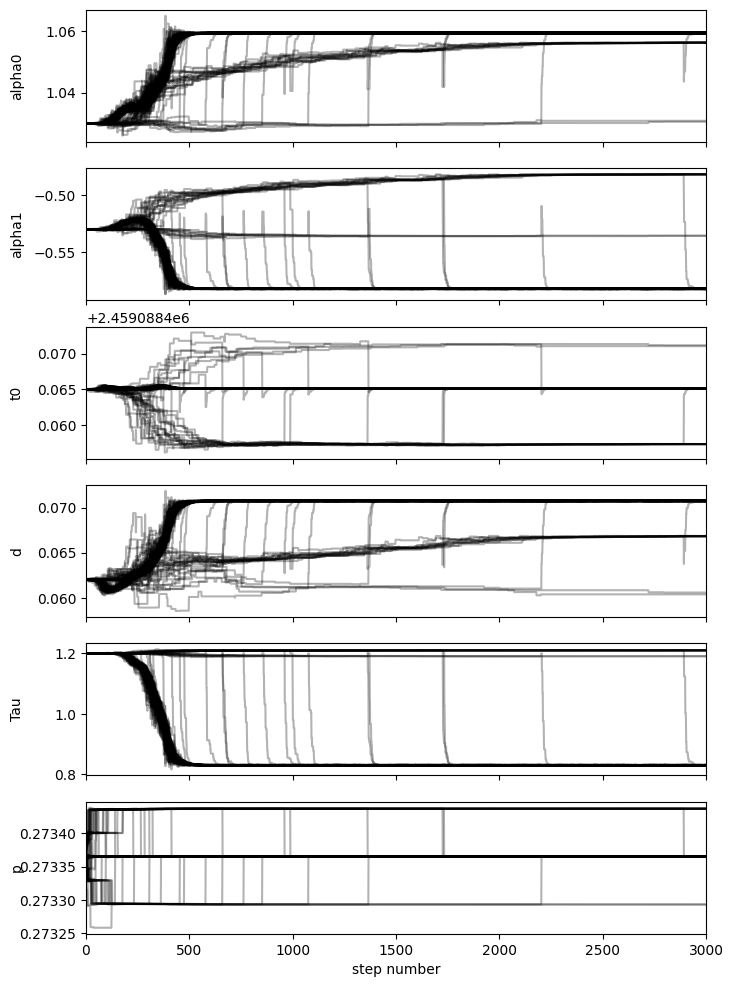

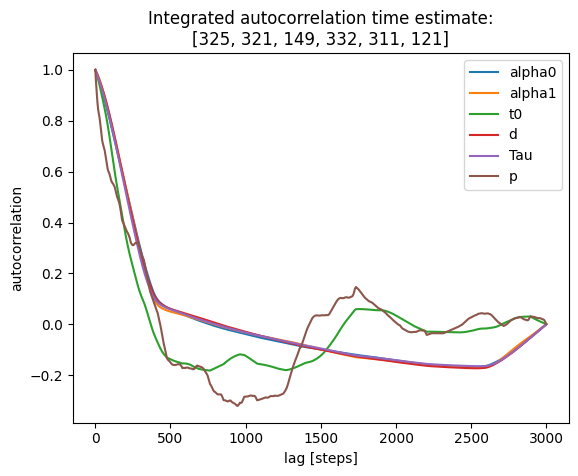

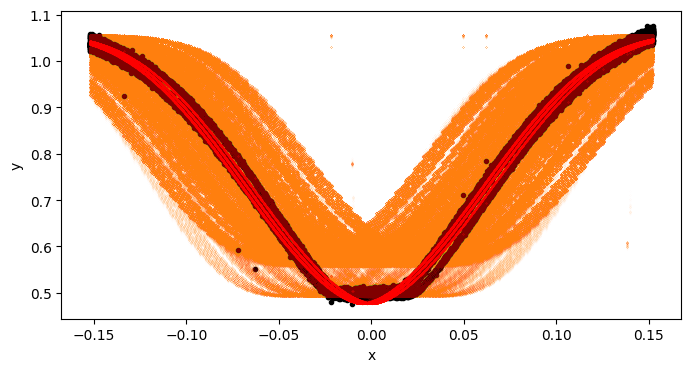

mean_alpha0, mean_alpha1, mean_t0_time, mean_d, mean_Tau, mean_p = 1.0592797098480238, -0.5819755516536751, 2459088.4650843143, 0.07072888545451855, 0.8301006490211187, 0.27336481428549675
std_t0: 0.002455888247751028
std_p: 2.3760109964694038e-05


In [90]:
mean_alpha0, mean_alpha1, mean_t0_time, mean_d, mean_Tau, mean_p, fit_params_p_stats  = etvp.run_mcmc_initial_fit_p(
    lc_f_data, 
    [1.03, -0.53, epoch_time_hjd_trial, 0.062, 1.2, period_trial],
    # nruns=20, discard=1,
    nruns=3000, discard=1000,
    autocorr_time_kwargs=dict(tol=20),  # the emcee defaults tol=50 seems to be too strict for our use case, tol of ~10 - 20 seems to be sufficient    
    pool=-2, 
    plot_chains=True, plot_autocorrelation=True, plot=True, 
    also_return_stats=True,
)

print("mean_alpha0, mean_alpha1, mean_t0_time, mean_d, mean_Tau, mean_p = " + ", ".join([str(v) for v in [mean_alpha0, mean_alpha1, mean_t0_time, mean_d, mean_Tau, mean_p]]))
print("std_t0:", fit_params_p_stats["std_t0"])
print("std_p:", fit_params_p_stats["std_p"])


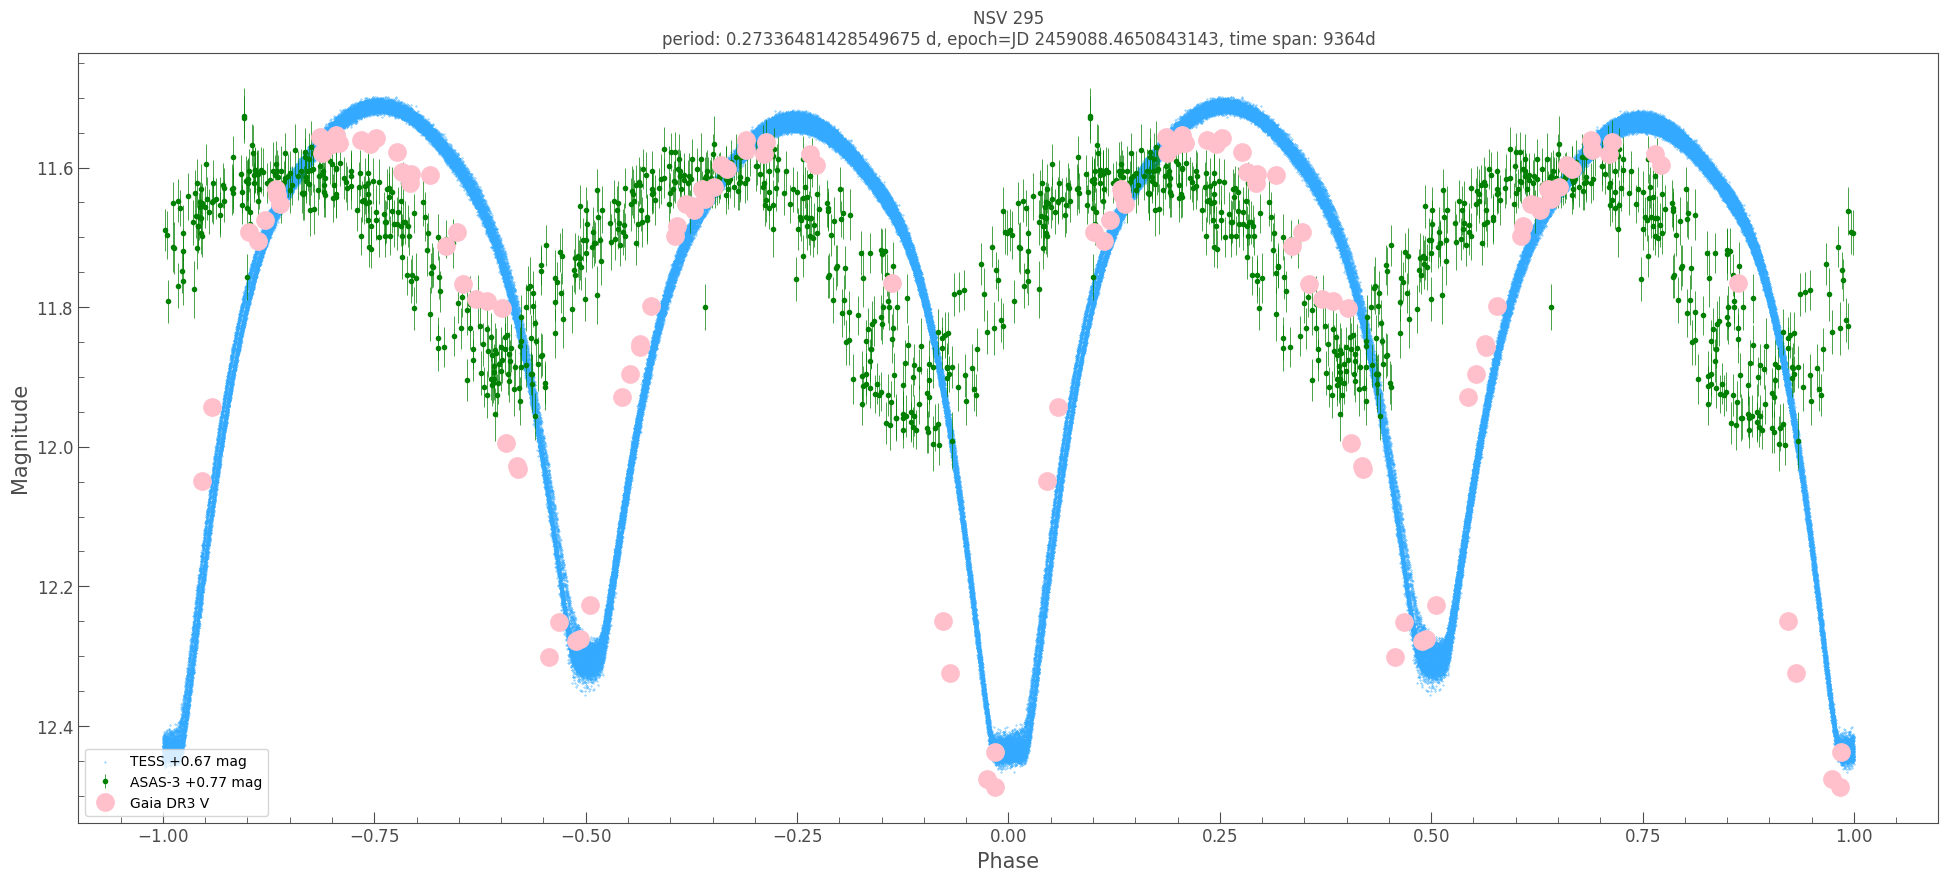

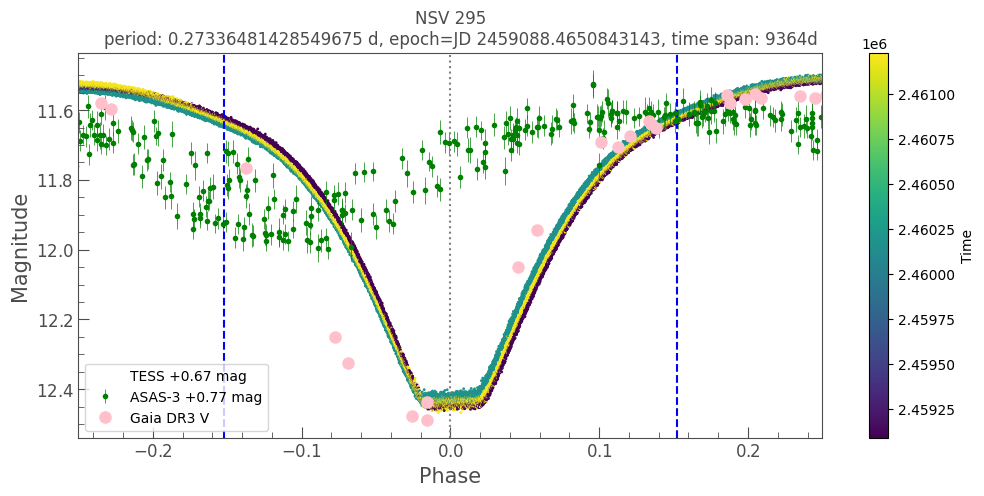

In [93]:
_p = 0.27336481428549675  # MCMC, std_p: 2.3760109964694038e-05
_t0 = 2459088.4650843143  # MCMC, std_t0: 0.002455888247751028

ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=_p, 
    epoch=Time(_t0, format="jd", scale="utc"),  
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1    
    figsize=(24, 10),
    target_name=primary_name,
    plot_options=plot_options,
);
ax.legend(loc="lower left");
ax.set_ylim(*ylim);

ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=_p,
    epoch=Time(_t0, format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
    target_name=primary_name,
    duration_hr=duration_hr_min_i_trial  ,  # for plotting only
    figsize=(12, 5), 
    plot_options=plot_options_zoom,
    # mag_shift_precision=2,
);
ax.legend(loc="lower left");
ax.axvline(0, c="gray", linestyle="dotted");
ax.set_xlim(-0.25, 0.25);  # to see primary in details
ax.set_ylim(*ylim);


## Periodograms of individual data sets

Period at max: 0.1366823785171304 d
Min / Max period tested: 0.010000000885951344 d 107229.23949998803 d
lightkurve.Periodogram properties:
      Attribute           Description    Units
---------------------- ----------------- -----
                nterms                 2      
              targetid         281728275      
          default_view            period      
                 label     TIC 281728275      
             ls_method    fastnifty_chi2      
frequency_at_max_power            7.3162 1 / d
             max_power            0.2978      
               nyquist          359.9712 1 / d
   period_at_max_power            0.1367     d
             frequency array (10722923,) 1 / d
                period array (10722923,)     d
                 power array (10722923,)      
                  meta    <class 'dict'>      


power,period,prominence,lower_hwhm,upper_hwhm,fwhm,period_ratio
,d,,d,d,d,
float64,float64,float64,float64,float64,float64,float64
0.3,0.1366823785171304,0.3,4.3787e-06,-4.278e-06,8.6567e-06,1.000
0.3,0.2733647570342608,0.3,8.9586e-06,-8.7353e-06,1.7694e-05,0.500
0.3,0.27347281957242764,0.2,9.158e-06,-7.5374e-06,1.6695e-05,0.500


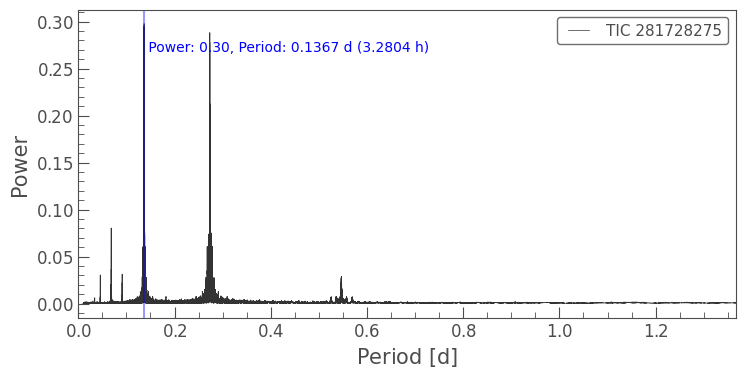

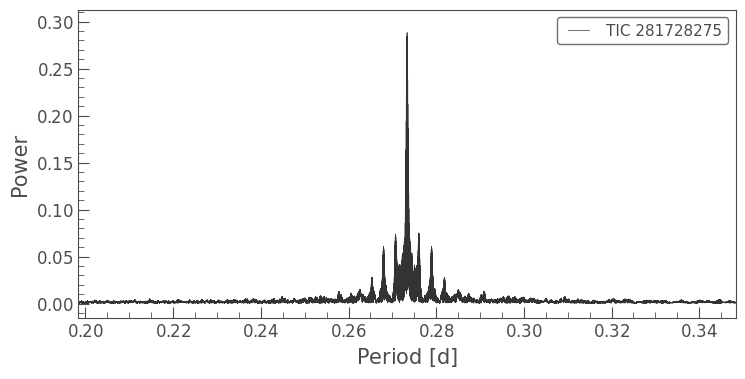

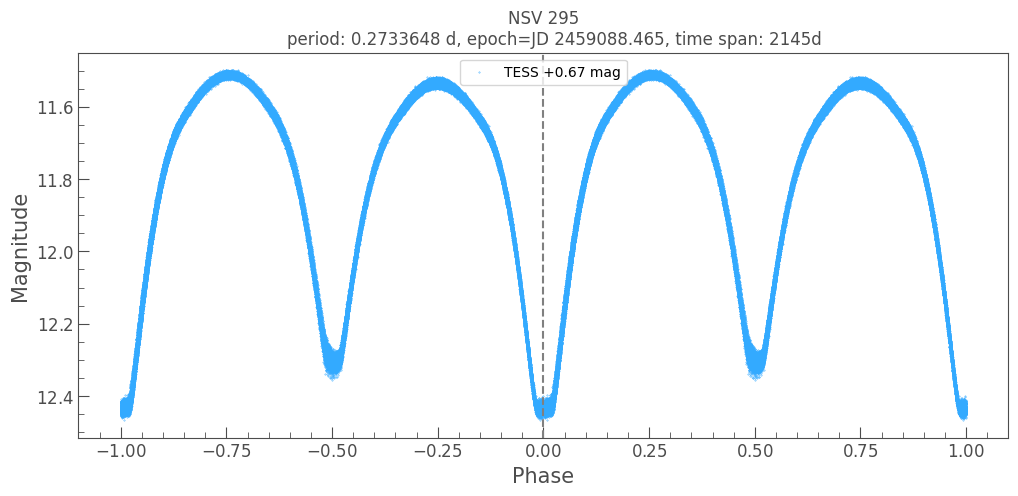

In [176]:
_lc = lke.to_normalized_flux_from_mag(lc_tess)

_pg = (
    _lc
    .to_periodogram(method="lombscargle",
                    ls_method="fastnifty_chi2", nterms=2,
                    # ls_method="fastchi2", nterms=2,
                    minimum_period=0.01,  # to stop wasting time of period that is way too short
                    oversample_factor=50,
                      )
     )
print(f"Period at max: {_pg.period_at_max_power}")
print(f"Min / Max period tested:", _pg.period.min(), _pg.period.max())
_pg.show_properties();

_peaks = lke_pg.find_peaks(_pg);
display(_peaks[:3])

# --- 

_period = _peaks["period"][1]

ax = lke_pg.plot_pg_n_mark_max(_pg, max_period_factor=10);

ax = _pg.plot(view="period")
ax.set_xlim(_period - 0.075, _period + 0.075);

ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    {"TESS": lc_combined_dict["TESS"]}, 
    # period=round(_pg.period_at_max_power.value, 7),
    period=round(_period, 7), 
    epoch=Time(epoch_time_hjd_trial, format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
    figsize=(12, 5),
    plot_options=[('scatter', {'c': '#3AF', 's': 0.1, 'alpha': 1.0})],
    target_name=primary_name,
);
ax.axvline(0, c="gray", linestyle="--");


Period at max: 0.13668280139622235 d
Min / Max period tested: 0.010000001919673719 d 48223.879257409586 d
lightkurve.Periodogram properties:
      Attribute                Description          Units
---------------------- ---------------------------- -----
                nterms                            2      
          default_view                       period      
                 label Gaia DR3 4921052482695108096      
             ls_method               fastnifty_chi2      
frequency_at_max_power                       7.3162 1 / d
             max_power                       0.2735      
               nyquist                       0.0441 1 / d
   period_at_max_power                       0.1367     d
             frequency             array (4822387,) 1 / d
                period             array (4822387,)     d
                 power             array (4822387,)      
                  meta               <class 'dict'>      
              targetid           <class 'NoneTy

power,period,prominence,lower_hwhm,upper_hwhm,fwhm,period_ratio
,d,,d,d,d,
float64,float64,float64,float64,float64,float64,float64
0.3,0.13668280139622235,0.3,1.3183e-05,-8.9531e-06,2.2137e-05,1.000
0.3,0.2733656027924447,0.3,2.5428e-05,-2.093e-05,4.6358e-05,0.500
0.2,0.020562519724022864,0.2,2.748e-07,-1.9268e-07,4.6748e-07,6.647


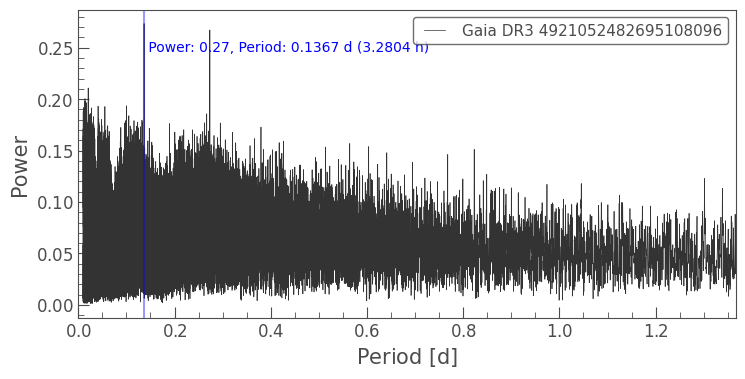

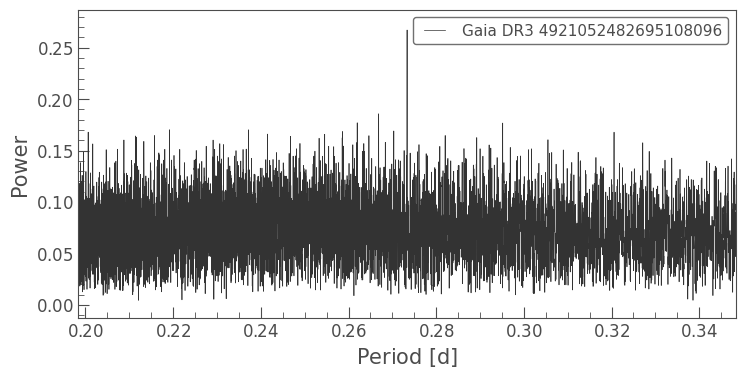

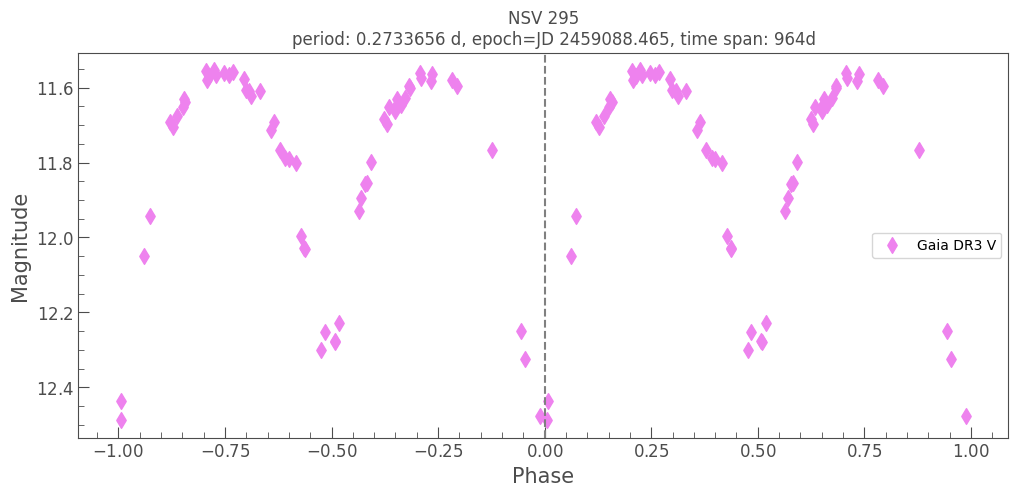

In [159]:
_lc = lke.to_normalized_flux_from_mag(lc_gdr3)

_pg = (
    _lc
    .to_periodogram(method="lombscargle",
                    ls_method="fastnifty_chi2", nterms=2,
                    # ls_method="fastchi2", nterms=2,
                    minimum_period=0.01,  # defautl grid' min period is ~22 d
                    oversample_factor=50,
                      )
     )
print(f"Period at max: {_pg.period_at_max_power}")
print(f"Min / Max period tested:", _pg.period.min(), _pg.period.max())
_pg.show_properties();

_peaks = lke_pg.find_peaks(_pg);
display(_peaks[:3])

# --- 

_period = _peaks["period"][1]

ax = lke_pg.plot_pg_n_mark_max(_pg, max_period_factor=10);

ax = _pg.plot()
ax.set_xlim(_period - 0.075, _period + 0.075);

ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    {"Gaia DR3 V": lc_combined_dict["Gaia DR3 V"]}, 
    # period=round(_pg.period_at_max_power.value, 7),
    period=round(_period, 7), 
    epoch=Time(epoch_time_hjd_trial, format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
    figsize=(12, 5),
    plot_options=[('scatter', {'marker': 'd', 's': 64, 'c': 'violet'})],
    target_name=primary_name,
);
ax.axvline(0, c="gray", linestyle="--");


In [162]:
display(_peaks[:10])

power,period,prominence,lower_hwhm,upper_hwhm,fwhm,period_ratio
,d,,d,d,d,
float64,float64,float64,float64,float64,float64,float64
0.1,0.088327738518955,0.1,0.00016388,-0.00017249,0.00033638,1.000
0.0,0.09688662791032662,0.0,0.00027262,-0.00023983,0.00051245,0.912
0.0,0.19377325582065322,0.0,0.00084699,-0.0012877,0.0021347,0.456
0.0,0.10728218884491102,0.0,0.00034753,-0.00024453,0.00059205,0.823
0.0,0.021869422572934616,0.0,1.2847e-05,-1.15e-05,2.4347e-05,4.039
0.0,0.012720992366852044,0.0,9.6709e-06,-4.4932e-06,1.4164e-05,6.943
0.0,0.01109980017800367,0.0,4.238e-06,-5.6376e-06,9.8756e-06,7.958
0.0,0.08115827922358528,0.0,0.00014026,-0.00024824,0.0003885,1.088


Period at max: 0.13668389108084136 d
Min / Max period tested: 0.010000000000345751 d 9998.700000345707 d
lightkurve.Periodogram properties:
      Attribute           Description     Units
---------------------- ------------------ -----
                nterms                  2      
          default_view             period      
                 label ASAS 004642-5437.4      
             ls_method     fastnifty_chi2      
frequency_at_max_power             7.3162 1 / d
             max_power             0.1316      
               nyquist             0.1686 1 / d
   period_at_max_power             0.1367     d
             frequency    array (999870,) 1 / d
                period    array (999870,)     d
                 power    array (999870,)      
                  meta     <class 'dict'>      
              targetid <class 'NoneType'>      


power,period,prominence,lower_hwhm,upper_hwhm,fwhm,period_ratio
,d,,d,d,d,
float64,float64,float64,float64,float64,float64,float64
0.1,0.13668389108084136,0.1,2.8345e-06,-3.9454e-06,6.7799e-06,1.000
0.1,0.2733677821616827,0.1,5.5128e-06,-9.9971e-06,1.551e-05,0.500
0.1,0.1882001957601586,0.1,6.3204e-06,-6.5389e-06,1.2859e-05,0.726


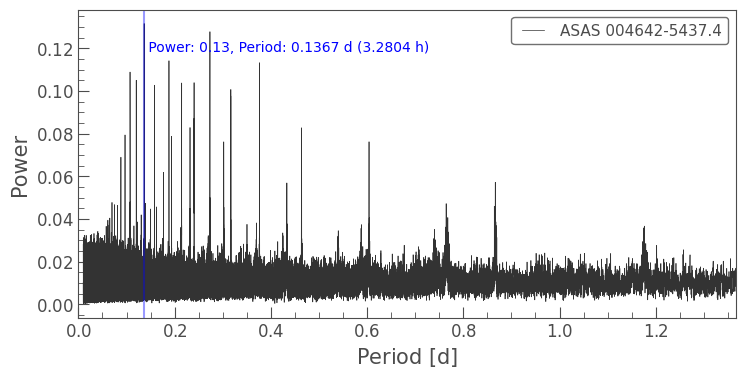

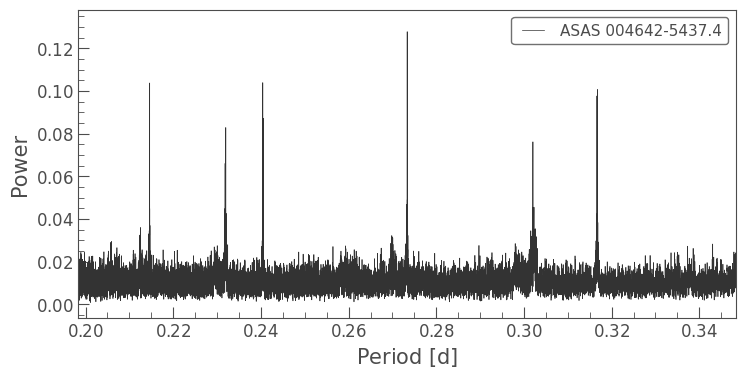

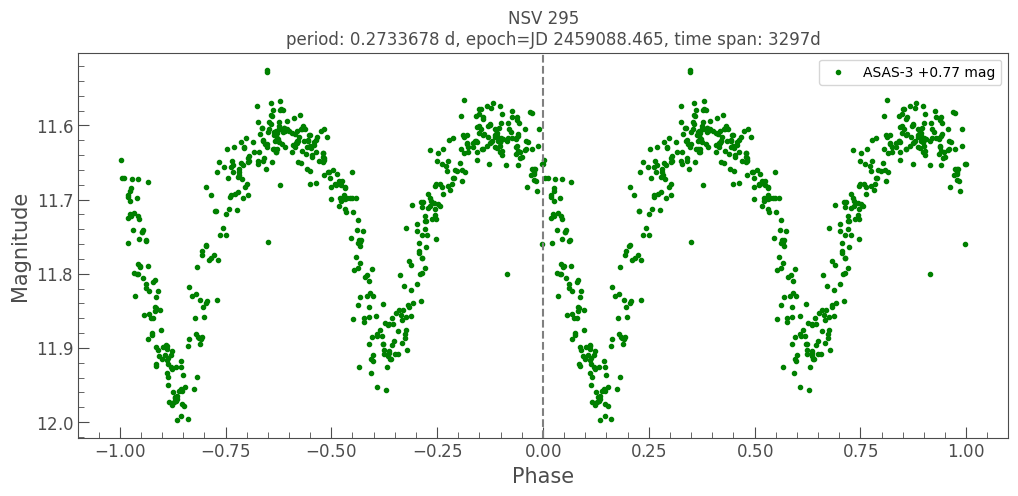

In [234]:
_lc = lke.to_normalized_flux_from_mag(lc_asas3)

_pg = (
    _lc
    .to_periodogram(method="lombscargle",
                    ls_method="fastnifty_chi2", nterms=2,
                    # ls_method="fastchi2", nterms=2,
                    minimum_period=0.01,  # defautl grid' min period is ~6 d
                    oversample_factor=2000,
                      )
     )
print(f"Period at max: {_pg.period_at_max_power}")
print(f"Min / Max period tested:", _pg.period.min(), _pg.period.max())
_pg.show_properties();

_peaks = lke_pg.find_peaks(_pg);
display(_peaks[:3])

# --- 

_period = _peaks["period"][1]

ax = lke_pg.plot_pg_n_mark_max(_pg, max_period_factor=10);

ax = _pg.plot()
ax.set_xlim(_period - 0.075, _period + 0.075);

ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    {"ASAS-3": lc_combined_dict["ASAS-3"]}, 
    # period=round(_pg.period_at_max_power.value, 7),
    period=round(_period, 7), 
    epoch=Time(epoch_time_hjd_trial, format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
    figsize=(12, 5),
    plot_options=[('scatter', {'marker': '.', 's': 36, 'c': 'green'})],
    target_name=primary_name,
);
ax.axvline(0, c="gray", linestyle="--");


In [ ]:
# # export the combined data (in mag,, shifted to ASAS-3) for analysis outside
# _lc = lke.stitch_lc_dict(lc_combined_dict, normalize=False).remove_nans()

# # make output importable to VStar

# # VStar seems to treat 4th column as observer code and do some validation, we I change the value to something like observer code
# _lc["source"][_lc["source"] == "ASAS-3"] = "ASAS3"
# _lc["source"][_lc["source"] == "Gaia DR3 V"] = "GDR3V"
# # print(np.unique(_lc["source"]))

# _lc.to_csv(f"{lk_download_dir}/tmp_in/tic281728275_asas3_gdr3_tess.csv", overwrite=True)
# # step for AoV: 0.00000001


## Final epoch / period / duration

In [178]:
#  Periods
# TESS
0.27336476 # LS
0.27336481  # MCMC (TESS + GDR3, but mostly GDR3)
# Gaia DR3 
0.2733656  # LS
0.2733661  # Gaia DR3 Variable value
# ASAS-3
0.2733678  # LS
0.2733669  # existing VSX value
""

''

Adopted period / epoch / duration_hr:  0.27336474 2459088.465 2.0


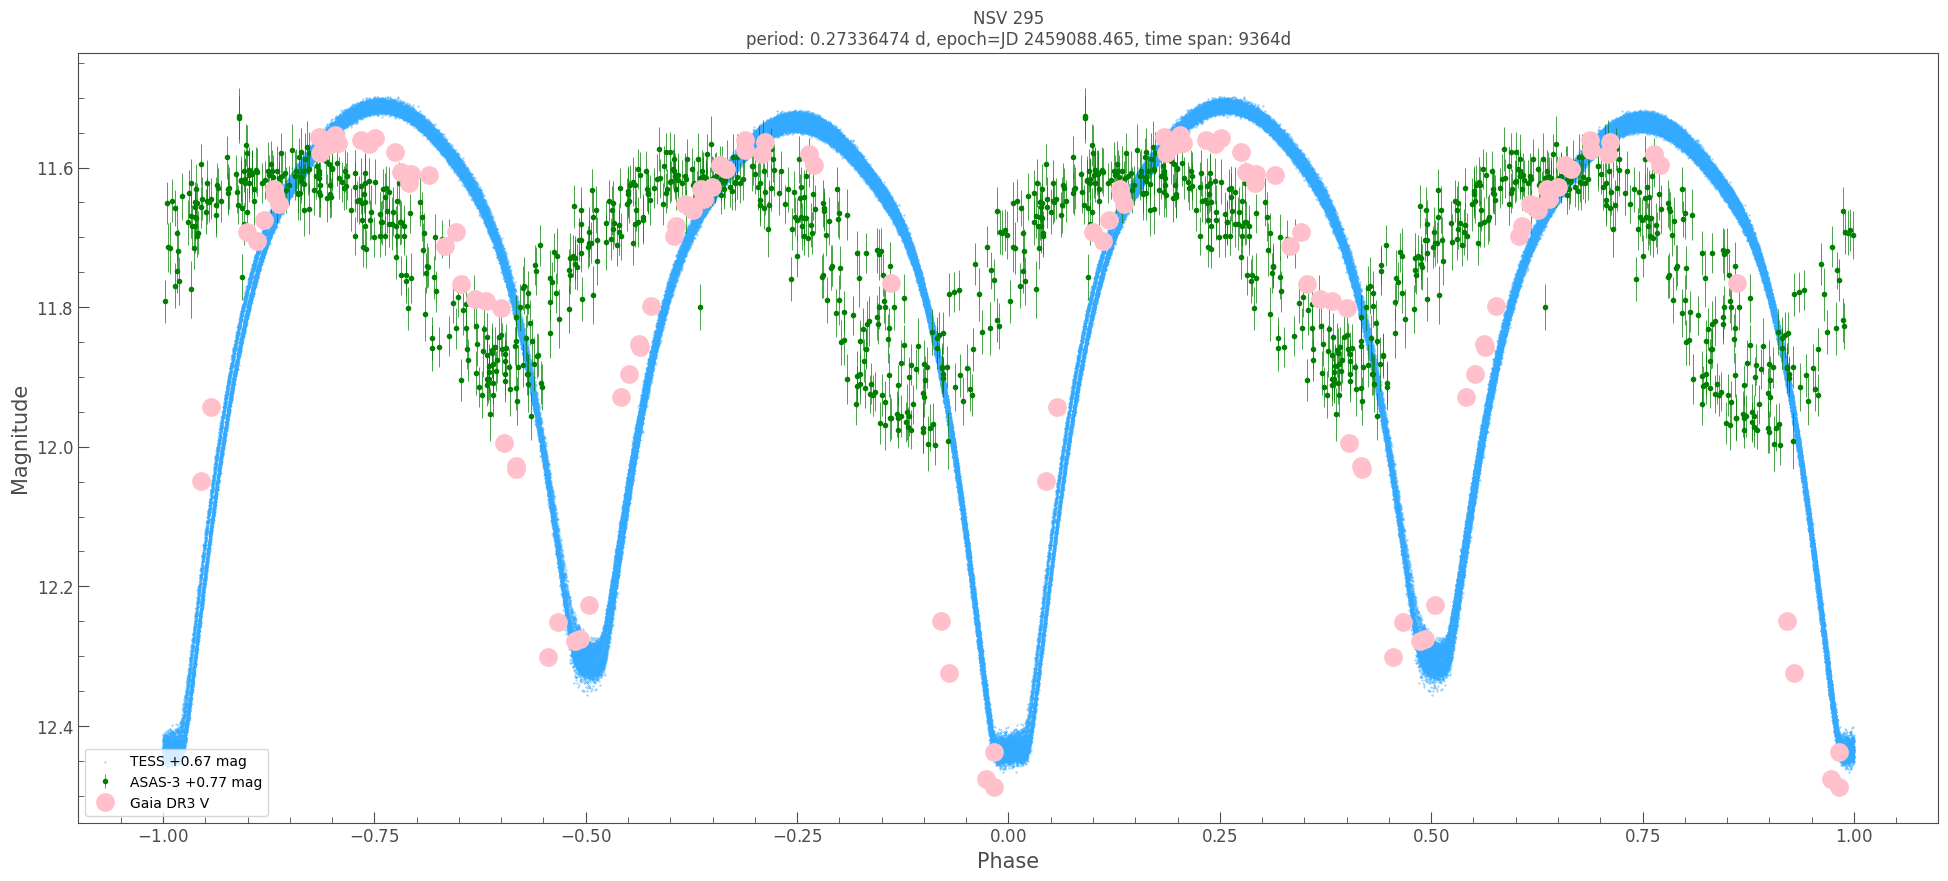

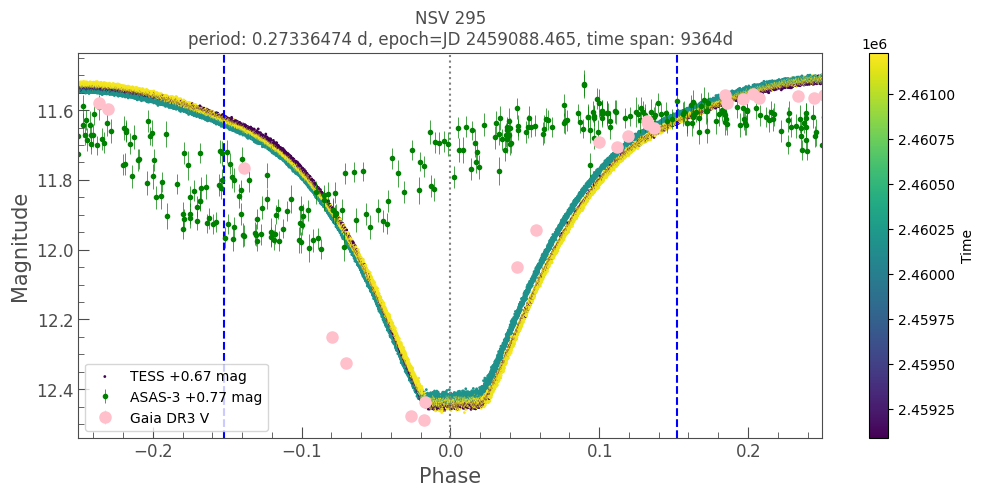

In [186]:
# reload(lkem)

period_final = 0.27336474  # best TESS period from LS 0.27336476 , further tweaked from inspection
epoch_time_hjd_final = epoch_time_hjd_trial
duration_hr_min_i_final = duration_hr_min_i_trial  # duration not really defined for EW, most for zoom plot for casual inspection

# epoch_time_min_ii_hjd_final = epoch_time_min_ii_hjd_trial
# epoch_phase_min_ii_final   = abs(epoch_time_min_ii_hjd_final - float(epoch_time_hjd_final)  ) / period_final  % 1
# epoch_phase_min_ii_final  = round(epoch_phase_min_ii_final, 4)  # precsion from eyeballing zoomed plot
# duration_hr_min_ii_final = duration_hr_min_ii_trial


print("Adopted period / epoch / duration_hr: ", period_final, epoch_time_hjd_final, duration_hr_min_i_final)  # ,  epoch_phase_min_ii_final,  duration_hr_min_ii_final

# --- Plot them to verify ---

plot_options = lkem.get_default_plot_multi_bands_options_copy()
plot_options[2][1]["markersize"] = 25

ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_final,
    epoch=Time(epoch_time_hjd_final   , format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1    
    figsize=(24, 10),
    target_name=primary_name,
    plot_options=plot_options,
);
ax.legend(loc="lower left");
ylim = (None, None)
ax.set_ylim(*ylim);

# zoom plot Min I
# - make TESS more visible:  larger dots
plot_options_zoom = lkem.get_default_plot_multi_bands_options_copy()
plot_options_zoom[0][1]["s"] = 1
plot_options_zoom[0][1]["c"] = "_time_"
plot_options_zoom[2][1]["markersize"] = 16


ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_final,
    epoch=Time(epoch_time_hjd_final, format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
    target_name=primary_name,
    duration_hr=duration_hr_min_i_final  ,  # for plotting only
    figsize=(12, 5), 
    plot_options=plot_options_zoom,
    # mag_shift_precision=2,
);
ax.legend(loc="lower left");
ax.axvline(0, c="gray", linestyle="dotted");
ax.set_xlim(-0.25, 0.25);  # to see primary in details
ax.set_ylim(*ylim);


# # zoom plot Min II
# ax, lc_f_res = lkem.fold_n_plot_multi_bands(
#     lc_combined_dict,
#     period=period_final,
#     epoch=Time(epoch_time_min_ii_hjd_final, format="jd", scale="utc"),
#     phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
#     target_name=primary_name,
#     duration_hr=duration_hr_min_ii_final  ,  # for plotting only
#     figsize=(12, 5),
#     plot_options=plot_options_zoom,
#     # mag_shift_precision=2,
# );
# ax.legend(loc="lower left");
# ax.axvline(0, c="gray", linestyle="dotted");
# ax.set_xlim(-0.007, 0.007);  # to see primary in details
# ax.set_ylim(9.97, 9.952);


### Magnitude Range

np.float64(0.94)

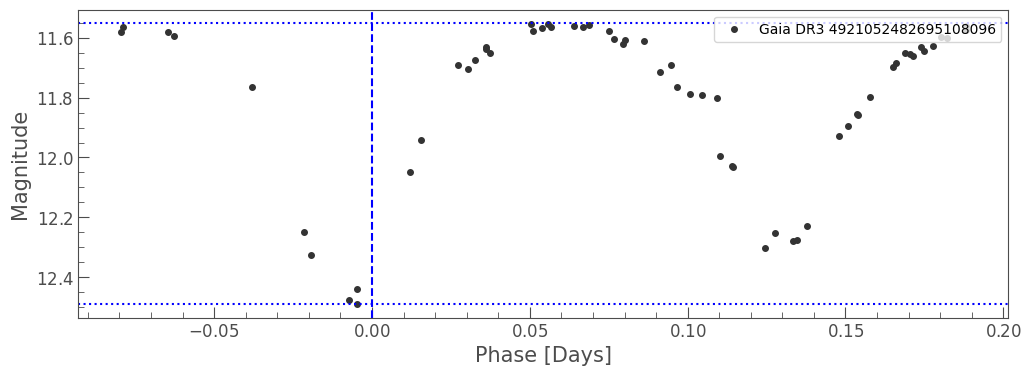

In [279]:

lc = lc_combined_dict["Gaia DR3 V"].remove_nans()
lc_f_b = lc.fold(epoch_time=epoch_time_hjd_final, period=period_final, wrap_phase=period_final * 0.7 * u.d);

max_flux_vmag = np.round(lc.flux.min().value, 2)
min_flux_vmag = np.round(lc.flux.max().value, 2)


ax = tplt.scatter(lc_f_b, s=64, figsize=(12, 4));
ax.legend(loc="upper right");
ax.axvline(0, c="blue", linestyle="--");

ax.axhline(max_flux_vmag, c="blue", linestyle="dotted");
ax.axhline(min_flux_vmag, c="blue", linestyle="dotted");

amp_flux_vmag = round(min_flux_vmag - max_flux_vmag, 3)
amp_flux_vmag

## Plots for VSX

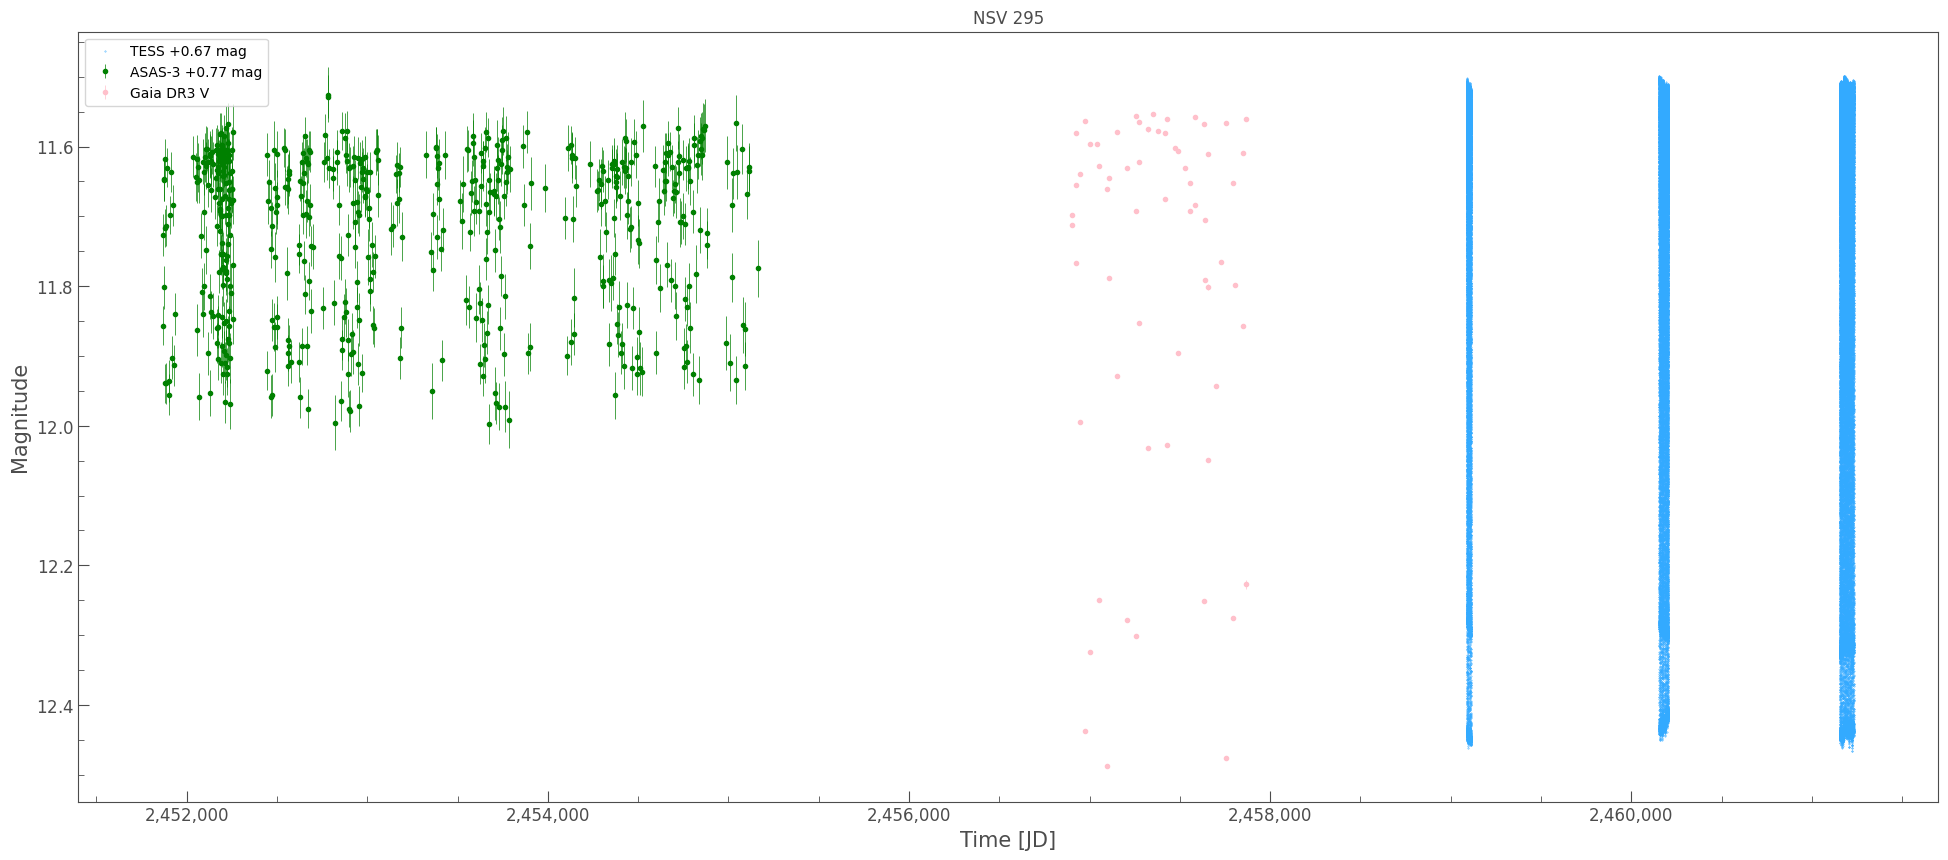

In [212]:
# reload(lkem)

ax = lkem.plot_multi_bands(lc_combined_dict, figsize=(24, 10), target_name=primary_name);

### Phase Plot

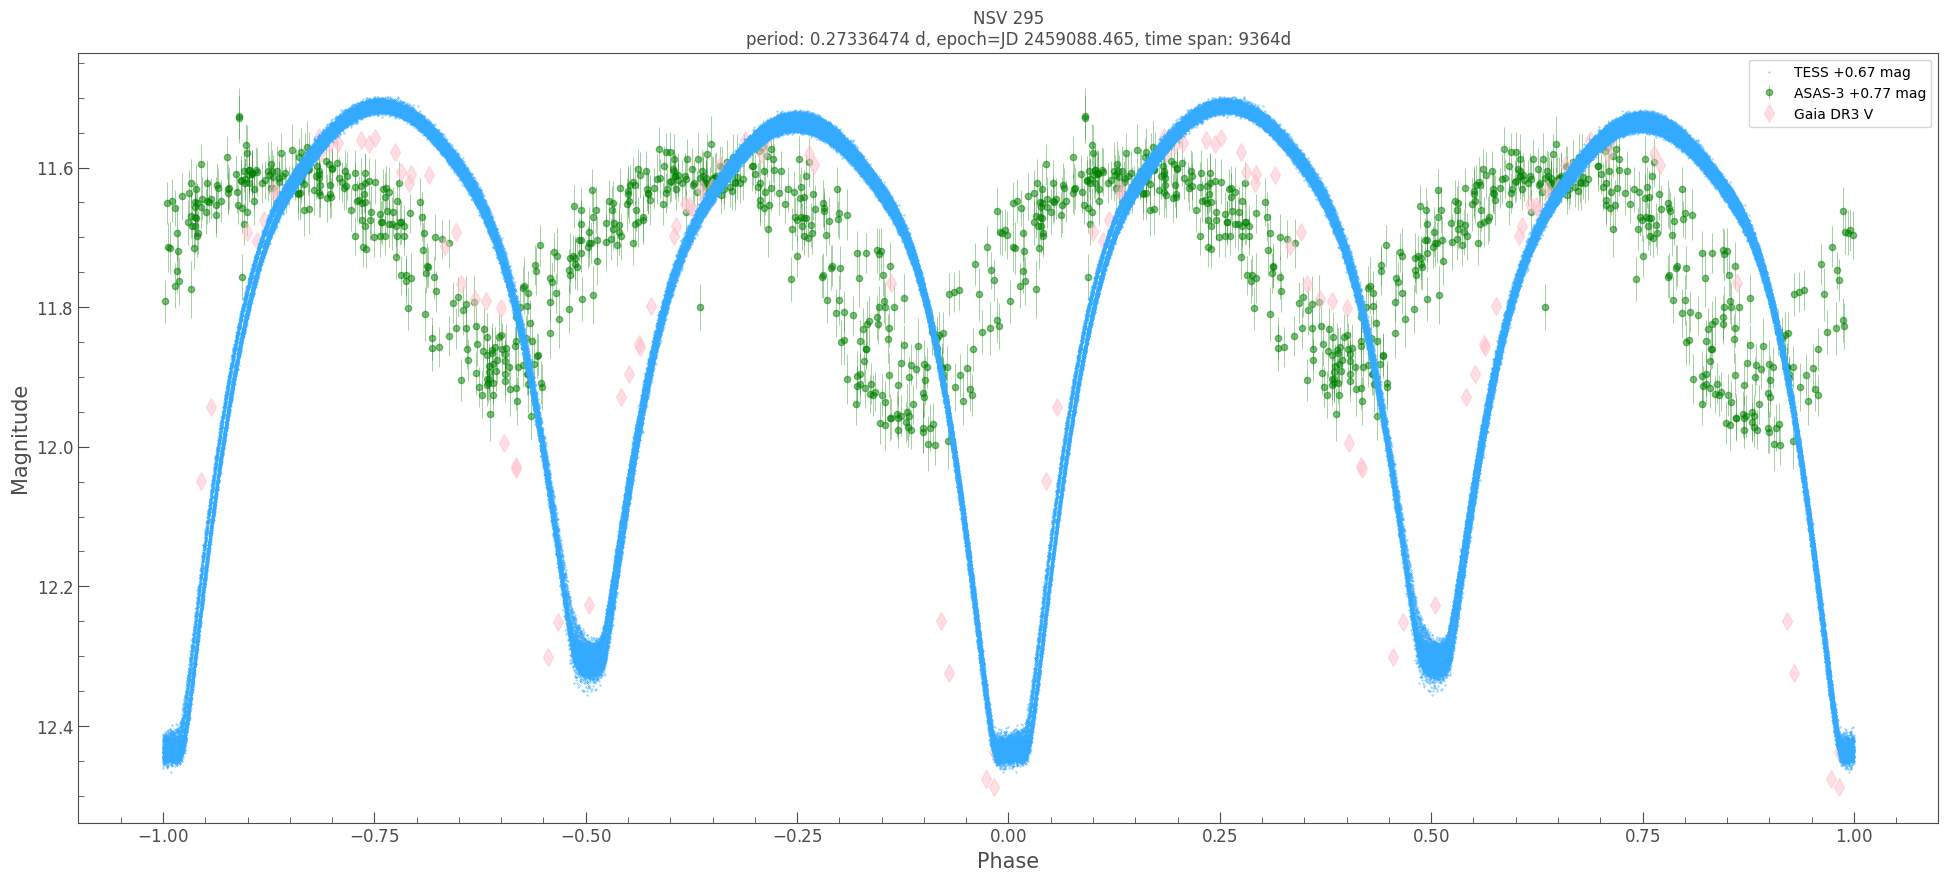

In [223]:
# emphasize TESS
plot_options = lkem.get_default_plot_multi_bands_options_copy()
plot_options[0] = ('scatter', {'c': '#3AF', 's': 0.1, 'alpha': 1.0, 'zorder': 9})
plot_options[1] = ('errorbar', {'marker': '.', 'markersize': 9, 'c': 'green', 'linewidth': 0.5, 'ls': 'none', 'alpha': 0.5 })
plot_options[2] = ('errorbar', {'marker': 'd', 'markersize': 9, 'c': 'pink', 'linewidth': 0.5, 'ls': 'none', 'alpha': 0.5 })

ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_final,  # TESS period
    epoch=Time(epoch_time_hjd_final, format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
    figsize=(24, 10),
    target_name=primary_name,
    plot_options=plot_options,
);

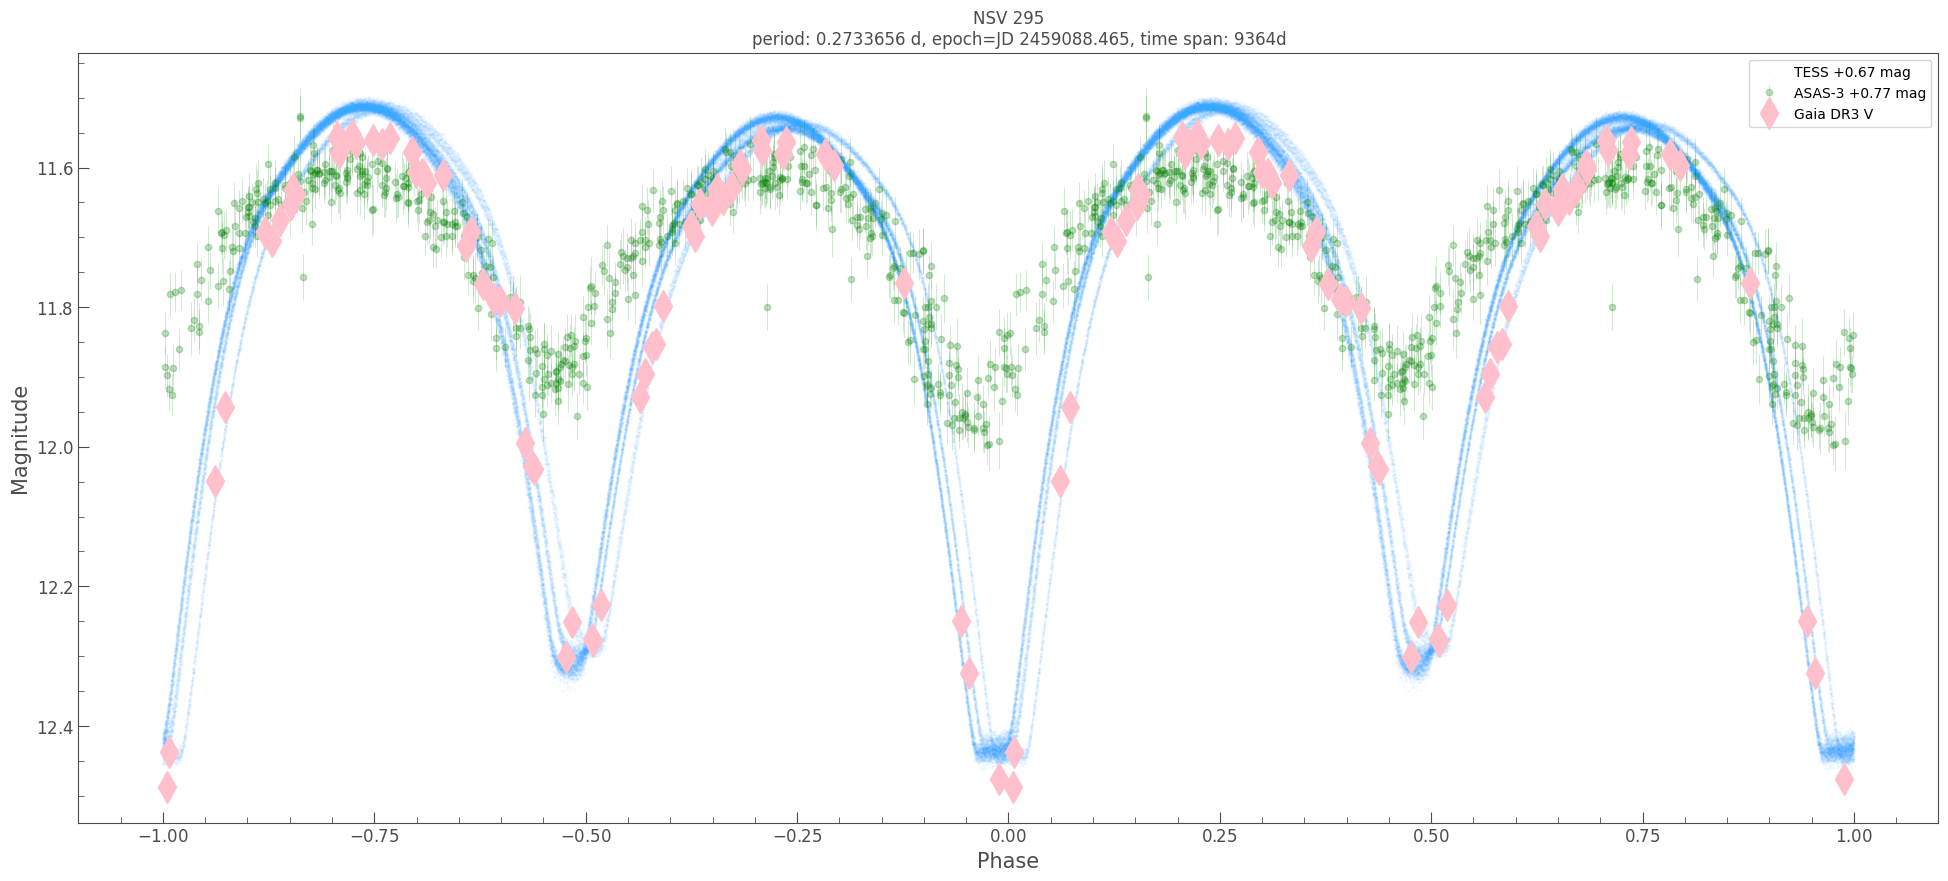

In [273]:
# emphasize Gaia DR3
# period_gdr3 = 0.2733661  # Gaia DR3 Variable value
period_gdr3 = 0.2733656  # LS, visually better


plot_options = lkem.get_default_plot_multi_bands_options_copy()
plot_options[0] = ('scatter', {'c': '#3AF', 's': 0.1, 'alpha': 0.1})
plot_options[1] = ('errorbar', {'marker': '.', 'markersize': 9, 'c': 'green', 'linewidth': 0.5, 'ls': 'none', 'alpha': 0.25 })
plot_options[2] = ('errorbar', {'marker': 'd', 'markersize': 16, 'c': 'pink', 'linewidth': 0.5, 'ls': 'none', 'alpha': 1.0, 'zorder': 9 })

ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_gdr3,  # TESS period
    epoch=Time(epoch_time_hjd_final, format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
    figsize=(24, 10),
    target_name=primary_name,
    plot_options=plot_options,
);

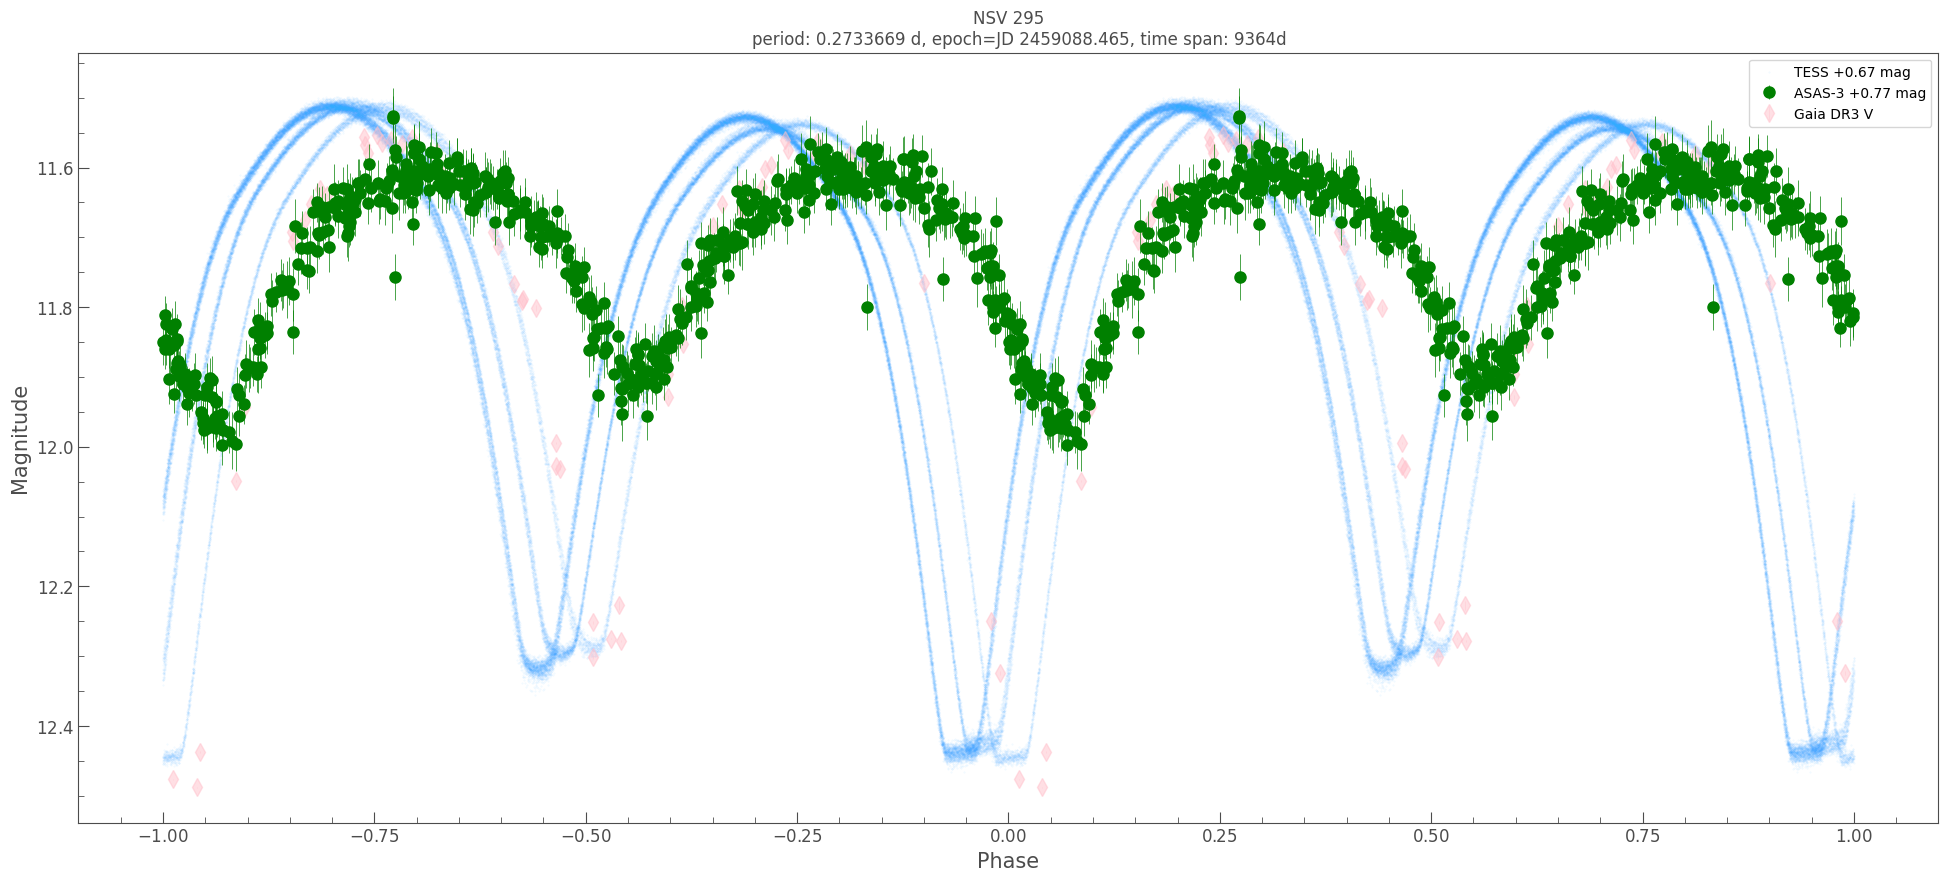

In [265]:
# emphasize ASAS-3
# period_asas3 = 0.2733678  # LS
period_asas3 = 0.2733669  # existing VSX value from ASAS-3, visually better


plot_options = lkem.get_default_plot_multi_bands_options_copy()
plot_options[0] = ('scatter', {'c': '#3AF', 's': 0.1, 'alpha': 0.1})
plot_options[1] = ('errorbar', {'marker': '.', 'markersize': 16, 'c': 'green', 'linewidth': 0.5, 'ls': 'none', 'alpha': 1.0, 'zorder': 9 })
plot_options[2] = ('errorbar', {'marker': 'd', 'markersize': 9, 'c': 'pink', 'linewidth': 0.5, 'ls': 'none', 'alpha': 0.5 })

ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_asas3,
    epoch=Time(epoch_time_hjd_final, format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
    figsize=(24, 10),
    target_name=primary_name,
    plot_options=plot_options,
);

## VSX Report Table

In [235]:
def report_to_df(report):
    df = pd.DataFrame()
    df["Field"] = report.keys()
    df["Value"] = report.values()
    return df

In [258]:
# Get time range of the data set
for _lc in [lc_asas3, lc_gdr3, lc_tess]:
    print(_lc.time.min().to_value("iso"), _lc.time.max().to_value("iso"))

2000-11-20 01:27:14.112 2009-11-30 04:33:35.136
2014-09-01 09:52:40.512 2017-04-22 21:20:21.869
2020-08-26 17:51:19.008 2026-07-11 13:25:25.594


In [280]:
import bibs_utils
reload(bibs_utils)

BIBS = bibs_utils.BIBS

other_names = "UCAC4 177-000733,TIC 281728275,2MASS J00464211-5437296,Gaia DR3 4921052482695108096"  # ExoFOP + SIMBAD
other_names += ",ASAS J004642-5437.4"  # ASAS-3 data
other_names += ",ASASSN-V J004642.23-543730.0"  # ASAS-SN Var
other_names += ",WISEA J004642.19-543730.5"  # ExoFOP + Vizier -- https://vizier.cds.unistra.fr/viz-bin/VizieR-5?-ref=VIZ6a8f7d77124a1f&-out.add=.&-source=II/328/allwise&AllWISE===J004642.19-543730.5
other_names += ",TYC 8466-913-2,WDS J00467-5437B"  # TODO: other useful names from SIMBAD / Vizier

remarks = (
    f"{BIBS.GAIA_DR3_VAR_B} identified the fainter TYC 8466-913-2 as the variable. "
    f"Period decreased over time. The period in the main table is from the most recent TESS data. "
    f"The best periods: {period_asas3} d (2000-2009, ASAS-3), {period_gdr3} d (2014-2017, Gaia DR3 V), {period_final} d (2020-2026, TESS)."
)

revision_comment = (
    f"Period, epoch from TESS, ASAS-3, and transformed Gaia DR3 data. Range from transformed Gaia DR3 data. "
    f"Identification from {BIBS.GAIA_DR3_VAR_B}. Spectral type from {BIBS.GAIA_DR3_ASTROPHY_B}. Gaia DR3 position."
    f" Sebatsian: Existing names TYC 8466-913-1, GSC 08466-00913, 2MASS J00464204-5437254 should be removed as they identify the brighter comapnion."
# GSC: https://vizier.cds.unistra.fr/viz-bin/VizieR-4?-source=I/255&-c=11.675437%2C%20-54.624920&-c.eq=J2000&-c.r=5&-c.u=arcsec&-c.geom=r&-out.add=_r&-out.add=_p&%2F%2Foutaddvalue=default
# 2MASS: https://vizier.cds.unistra.fr/viz-bin/VizieR-4?-source=II/246&-c=11.675437%2C%20-54.624920&-c.eq=J2000&-c.r=5&-c.u=arcsec&-c.geom=r&-out.add=_r&-out.add=_p&%2F%2Foutaddvalue=default
)


vsx_report = dict(
    Position=f"{target_coord.ra.value:.6f}, {target_coord.dec.value:.6f}",  
    # Primary_Name=primary_name,  # no change
    Other_Names=other_names,
    # Variable_Type="",  # EW: no change
    # Variable_Type_Uncertain=False,  
    Spectral_Type="K",  # Gaia DR3
    Spectral_Type_Uncertain=False,
    Maximum_Magnitude=max_flux_vmag,  # Gaia DR3 V
    Maximum_Magnitude_band="V",
    Minimum_Magnitude=min_flux_vmag,
    Minimum_Magnitude_band="V",  
    Minimum_Is_Amplitude=False,
    Period=f"{period_final}",  # need to pass a string, or the default pandas dipaly will round the value to 6 decimal places
    # Period_Uncertain=True,
    Epoch=epoch_time_hjd_final,
    # Discoverer="",
    Remarks=remarks,
    Revision_Comment=revision_comment,
    Reference0_Name=BIBS.TESS_N,
    Reference0_Bib=BIBS.TESS_B,
    Reference1_Name=BIBS.GAIA_DR3_N,
    Reference1_Bib=BIBS.GAIA_DR3_B,
    # Reference2_Name=BIBS.ASAS3_N,  # already in the entry
    # Reference2_Bib=BIBS.ASAS3_B,
    Reference3_Name=BIBS.GAIA_DR3_VAR_N,
    Reference3_Bib=BIBS.GAIA_DR3_VAR_B,
    Reference4_Name=BIBS.GAIA_DR3_ASTROPHY_N,
    Reference4_Bib=BIBS.GAIA_DR3_ASTROPHY_B,
)

def print_long_fields(report):
    other_names_list = report["Other_Names"].split(",")
    print("Other Names (1 line each):")
    print("\n".join(other_names_list))
    print("")
    print(report["Remarks"])
    print("")
    print(report["Revision_Comment"])

print_long_fields(vsx_report)
with pd.option_context('display.max_colwidth', None):
    display(report_to_df(vsx_report))

# Uploaded plots with  descriptions
# tic281728275_phase_plot_eclipse_multi_periods.gif  - saved as gif to compress it to a smaller size (to be within 1Mb limit in VSXC)
print("""
tic281728275_phase_plot_eclipse_multi_periods.gif : EW Phase Plots, 3 periods - EW Phase Plots of the target from TESS, ASAS-3, and transformed Gaia DR3 data; 
one plot each for the best period of the individual data set, epoch fixed with the one in main table. Outliers truncated.
""")


Other Names (1 line each):
UCAC4 177-000733
TIC 281728275
2MASS J00464211-5437296
Gaia DR3 4921052482695108096
ASAS J004642-5437.4
ASASSN-V J004642.23-543730.0
WISEA J004642.19-543730.5
TYC 8466-913-2
WDS J00467-5437B

2022yCat.1358....0G identified the fainter TYC 8466-913-2 as the variable. Period decreased over time. The period in the main table is from the most recent TESS data. The best periods: 0.2733669 d (2000-2009, ASAS-3), 0.2733656 d (2014-2017, Gaia DR3 V), 0.27336474 d (2020-2026, TESS).

Period, epoch from TESS, ASAS-3, and transformed Gaia DR3 data. Range from transformed Gaia DR3 data. Identification from 2022yCat.1358....0G. Spectral type from 2023A&A...674A..26C. Gaia DR3 position. Sebatsian: Existing names TYC 8466-913-1, GSC 08466-00913, 2MASS J00464204-5437254 should be removed as they identify the brighter comapnion.


,Field,Value
0,Position,"11.675437, -54.624920"
1,Other_Names,"UCAC4 177-000733,TIC 281728275,2MASS J00464211-5437296,Gaia DR3 4921052482695108096,ASAS J004642-5437.4,ASASSN-V J004642.23-543730.0,WISEA J004642.19-543730.5,TYC 8466-913-2,WDS J00467-5437B"
2,Spectral_Type,K
3,Spectral_Type_Uncertain,False
4,Maximum_Magnitude,11.55
5,Maximum_Magnitude_band,V
6,Minimum_Magnitude,12.49
7,Minimum_Magnitude_band,V
8,Minimum_Is_Amplitude,False
9,Period,0.27336474



tic281728275_phase_plot_eclipse_multi_periods.gif : EW Phase Plots, 3 periods - EW Phase Plots of the target from TESS, ASAS-3, and transformed Gaia DR3 data; 
one plot each for the best period of the individual data set, epoch fixed with the one in main table. Outliers truncated.



# Scratch